# 2b. Heating Oil Meta-Model
### Heating Oil Futures (ho1s)

In this notebook we develop the meta-model for heating oil (ho1s). Meta-labelling uses a secondary model to decide whether to act on a primary model's signal. The primary signal says which way to trade, and the meta-model gives each of those signals a probability of being a genuine opportunity rather than noise.

We start from the assembled feature matrix built in notebook 1, which gives every instrument a common set of base features. On top of that we add a few heating oil specific features, the latent regime features, and the primary-signal features, then reduce everything with PCA, label the trades with the triple-barrier method, and compare a range of models. Every feature is strictly backward looking, so nothing here uses information from the future.

## 1. Imports

We load the standard scientific Python stack together with scikit-learn, XGBoost and Keras. These cover the data handling, the classical models, and the neural networks used later on.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline

from hmmlearn.hmm import GaussianHMM

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import xgboost as xgb

# Reproducibility: fix every RNG (NumPy, Python, TensorFlow) to one seed.
# We re-seed inside each model builder too, so neural-net weight init does not
# depend on cell run-order. enable_op_determinism() makes TF ops themselves
# deterministic so a clean top-to-bottom CPU run reproduces the exact results.
import os
os.environ["PYTHONHASHSEED"] = "42"
import random
random.seed(42)
np.random.seed(42)
keras.utils.set_random_seed(42)   # seeds Python, NumPy and TensorFlow together
tf.config.experimental.enable_op_determinism()

## 2. Load the Feature Matrix

We load the assembled feature matrix and, for heating oil, add the more specific data on top before running the triple-barrier method and the HMM for the regime state. The base features were built in the feature engineering notebook, and the idea is to keep a common set of base features that we can then enrich, so the meta-model has both general and heating oil specific information to work with.

In [2]:
features = pd.read_parquet('../data/processed/features/features.parquet')
features['date'] = pd.to_datetime(features['date'])
feat_dict = pd.read_csv('../data/processed/features/feature_dictionary.csv')

print('Shape:', features.shape)
print('Date range:', features['date'].min().date(), '→', features['date'].max().date())
print('Instruments:', sorted(features['instrument'].unique()))
print('Feature columns:', len(features.columns) - 3)  # minus date, instrument, primary_signal

Shape: (2512, 63)
Date range: 2020-01-03 → 2022-06-30
Instruments: ['cl1s', 'ho1s', 'ng1s', 'rb1s']
Feature columns: 60


## 3. Tier 1: Base Features

We keep the heating oil rows (ho1s), sort them by date, and recap the Tier 1 base features. These are the general price and volatility features that apply to any instrument, such as returns, momentum, rolling volatility, and the trend-scanning t-statistics. They describe what prices have actually done and form the backbone that the later tiers build on.

In [3]:
heating_oil = features[features['instrument'] == 'ho1s'].set_index('date').sort_index().copy()
print(heating_oil.shape)
heating_oil.head()

(628, 62)


,instrument,primary_signal,ret_1d,logret_1d,ret_5d,ret_10d,ret_20d,ret_60d,vol_20d,vol_60d,...,hmm_filt_calm,hmm_filt_turbulent,hmm_next_turbulent,hmm_regime_age,hmm_basket_turbulent_energy,kmeans_cluster_id,kmeans_cluster_size,primary_signal_lag1,primary_signal_lag5,primary_signal_streak
date,,,,,,,,,,,,,,,,,,,,,
2020-01-03,ho1s,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,ho1s,0.0,0.018428,0.018260,0.003840,0.020733,0.070145,0.083901,0.009637,0.012989,...,0.997088,0.002912,0.014447,41.0,0.998434,0.0,0.75,NaN,NaN,0.0
2020-01-07,ho1s,0.0,-0.013340,-0.013430,-0.008811,0.002759,0.051476,0.065666,0.010339,0.013120,...,0.997937,0.002063,0.013622,42.0,0.999299,0.0,0.50,0.0,NaN,1.0
2020-01-08,ho1s,0.0,-0.000738,-0.000738,-0.005593,0.005823,0.040905,0.064147,0.010218,0.013123,...,0.998498,0.001502,0.013077,43.0,0.999323,0.0,0.75,0.0,NaN,2.0
2020-01-09,ho1s,0.0,-0.036509,-0.037192,-0.032457,-0.032111,0.007769,0.007978,0.013438,0.013809,...,0.986853,0.013147,0.024386,44.0,0.985763,0.0,1.00,0.0,NaN,3.0


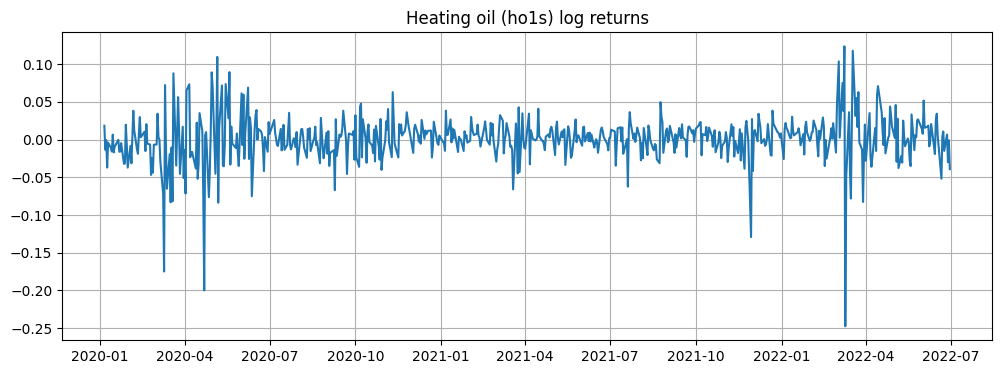

In [4]:
plt.figure(figsize=(12, 4))
plt.plot(heating_oil.index, heating_oil['logret_1d'])
plt.title('Heating oil (ho1s) log returns')
plt.grid(True)
plt.show()

In [5]:
base_cols = [
    'logret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'ret_60d',
    'vol_20d', 'vol_60d', 'parkinson_20d', 'garman_klass_20d',
    'vol_of_vol_20d', 'vol_ratio_5_60',
    'volume_z_20d', 'oi_z_60d', 'oi_change_5d', 'volume_oi_ratio',
    'rsi_14', 'macd', 'macd_signal', 'macd_hist',
    'bb_width_20', 'bb_pos_20', 'atr_14', 'adx_14',
    'dd_from_60d_high', 'runup_from_60d_low', 'days_since_60d_high',
    'trend_tstat_10', 'trend_tstat_20', 'trend_tstat_60',
    'trend_tstat_best', 'trend_H_best',
]
heating_oil[base_cols].tail()

,logret_1d,ret_5d,ret_10d,ret_20d,ret_60d,vol_20d,vol_60d,parkinson_20d,garman_klass_20d,vol_of_vol_20d,...,atr_14,adx_14,dd_from_60d_high,runup_from_60d_low,days_since_60d_high,trend_tstat_10,trend_tstat_20,trend_tstat_60,trend_tstat_best,trend_H_best
date,,,,,,,,,,,,,,,,,,,,,
2022-06-24,-0.015016,-0.046834,0.005698,0.171729,0.333064,0.022403,0.026035,0.028065,0.030394,0.001925,...,0.182136,28.013748,-0.050827,0.474442,4.0,-0.045950,5.871767,16.406592,16.406592,60.0
2022-06-27,0.006571,-0.045593,-0.008241,0.152688,0.358343,0.022043,0.025840,0.027878,0.030326,0.001838,...,0.175873,27.174847,-0.044570,0.484162,5.0,-0.197145,4.869147,16.182926,16.182926,60.0
2022-06-28,-0.030036,-0.023660,-0.029839,0.095966,0.308500,0.023087,0.026186,0.027881,0.030348,0.001713,...,0.173558,25.760322,-0.072840,0.440247,6.0,-1.128821,3.303068,15.645429,15.645429,60.0
2022-06-29,-0.001093,-0.029030,-0.011672,0.080741,0.335599,0.023014,0.025833,0.028994,0.031751,0.001545,...,0.179885,24.650561,-0.073853,0.438673,7.0,-3.282739,1.981078,15.008947,15.008947,60.0
2022-06-30,-0.039257,-0.078831,-0.076421,0.033908,0.277742,0.024937,0.026412,0.028618,0.030798,0.001667,...,0.182438,23.721758,-0.109506,0.383290,8.0,-5.717701,0.015677,13.906582,13.906582,60.0


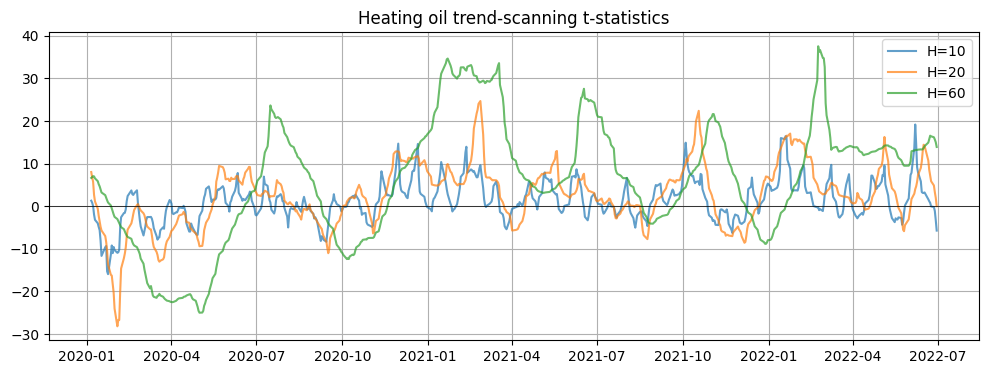

In [6]:
# Trend-scanning t-stats, Lecture 1, max |t| over several horizons
fig, ax = plt.subplots(figsize=(12, 4))
for h in [10, 20, 60]:
    ax.plot(heating_oil.index, heating_oil[f'trend_tstat_{h}'], label=f'H={h}', alpha=0.7)
ax.axhline(0, color='k', lw=0.5)
ax.set_title('Heating oil trend-scanning t-statistics')
ax.legend()
ax.grid(True)
plt.show()

## 4. Tier 2: Energy-Specific Features

Tier 2 adds features that are specific to the energy complex, for example crack spreads and cross-instrument spreads. Meta-labelling uses a secondary model to decide whether to act on the primary model's signal, and these features give that secondary model the energy-market context that a generic price feature would miss.

In [7]:
energy_cols = [
    'energy_basket_ret_5d', 'energy_basket_vol_20d',
    'rel_ret_vs_basket_5d', 'corr_to_basket_60d',
    'crack_321_proxy', 'crack_321_z_60d',
    'ho_cl_spread', 'rb_cl_spread',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'winter_indicator', 'driving_season',
]
heating_oil[energy_cols].tail()

,energy_basket_ret_5d,energy_basket_vol_20d,rel_ret_vs_basket_5d,corr_to_basket_60d,crack_321_proxy,crack_321_z_60d,ho_cl_spread,rb_cl_spread,month_sin,month_cos,dow_sin,dow_cos,winter_indicator,driving_season
date,,,,,,,,,,,,,,
2022-06-24,-0.082644,0.031510,0.035810,0.711436,0.000829,-0.164069,-2.127562,-1.151850,1.224647e-16,-1.0,-0.587785,-0.809017,0.0,1.0
2022-06-27,-0.076530,0.031862,0.030937,0.705382,-0.007808,-0.653094,-2.152614,-1.151036,1.224647e-16,-1.0,-0.951057,0.309017,0.0,1.0
2022-06-28,-0.014179,0.032228,-0.009481,0.692527,-0.035379,-2.143010,-2.200607,-1.180108,1.224647e-16,-1.0,0.000000,1.000000,0.0,1.0
2022-06-29,-0.001454,0.032284,-0.027576,0.679513,-0.001817,-0.235772,-2.221490,-1.172391,1.224647e-16,-1.0,0.951057,0.309017,0.0,1.0
2022-06-30,-0.025822,0.032777,-0.053009,0.689423,-0.016514,-1.046729,-2.242871,-1.186471,1.224647e-16,-1.0,0.587785,-0.809017,0.0,1.0


### 4.1 OVX Implied-Volatility Features

OVX is the CBOE Crude Oil Volatility Index, the oil-market analogue of VIX. Heating oil is a refined product priced largely off crude, so we use OVX as a broad forward-looking gauge of energy-market volatility, useful alongside the backward-looking `vol_20d`, `parkinson_20d`, and related features.

In this section we compute the following:
- `ovx_close` daily close
- `ovx_z` z-score on a 63-day window
- `iv_rv_ratio` implied vol (OVX) divided by realised vol (20-day annualised, in vol points)
- `ovx_slope` 5-day percentage change

**Why these features matter for meta-labelling**

The core idea is that options markets price in information that price-based features miss. When OVX is elevated, the market is paying up for crash protection, which usually means someone knows something or at least fears something. That is exactly the regime where a trend-following primary signal is most likely to get whipsawed.

`ovx_close` gives the raw implied vol level. On its own it is noisy, but it tells the meta-model whether the market is broadly calm or stressed. A bullish heating oil signal fired into a 50 plus OVX reading deserves a lot more scepticism than the same signal at OVX 25.

`ovx_z` normalises that level against the past 63 days. An OVX of 35 is unremarkable in a high-vol year but extreme in a quiet one. The z-score is what tells the meta-model whether the market is unusually fearful relative to its recent baseline, which is the number that matters for confidence calibration.

`iv_rv_ratio` is the most informative of the four. When implied vol runs well above realised vol, options are expensive and the market is pricing in a jump that has not happened yet. That tends to mean either a real catalyst is coming or the market is being irrational, and either way signal quality drops. When IV is below RV, options are cheap, the market has stopped hedging, and price action tends to be cleaner and more trend-friendly. The ratio is a direct read on how much the market trusts its own price signals.

`ovx_slope` captures whether fear is building or fading. A sharply rising OVX over 5 days, even from a moderate level, often precedes the kind of volatile, choppy price action that kills quantitative signals. A falling OVX after a spike is the opposite, the market is calming down and directional signals start working again. The slope gives the meta-model a sense of direction, not just level.

In [8]:
def load_ovx():
    """Return OVX close series indexed by date, or None if unavailable."""
    local = '../data/src/ovx.csv'
    df = pd.read_csv(local)
    date_col = 'Date' if 'Date' in df.columns else 'date'
    close_col = 'Close' if 'Close' in df.columns else 'close'
    df[date_col] = pd.to_datetime(df[date_col])
    return df.set_index(date_col)[close_col].rename('ovx_close').sort_index()


ovx_close = load_ovx()
if ovx_close is not None:
    ovx_close.index = pd.to_datetime(ovx_close.index).tz_localize(None)
    print('OVX rows:', len(ovx_close),
          'range:', ovx_close.index.min().date(), '→', ovx_close.index.max().date())
else:
    print('No OVX data available, subsequent OVX cells will be skipped.')

OVX rows: 4789 range: 2007-05-10 → 2026-05-21


In [9]:
if ovx_close is not None:
    ovx = ovx_close.to_frame()
    ovx['ovx_z'] = (
        (ovx['ovx_close'] - ovx['ovx_close'].rolling(63).mean())
        / ovx['ovx_close'].rolling(63).std()
    )
    ovx['ovx_slope'] = ovx['ovx_close'].pct_change(5)

    # iv_rv_ratio: implied (OVX, already in annualised vol points) over realised.
    # vol_20d is the std of daily logret, annualise by sqrt(252) and scale by 100 for vol points.
    rv_pts = heating_oil['vol_20d'] * np.sqrt(252) * 100
    ovx['iv_rv_ratio'] = ovx['ovx_close'] / rv_pts.reindex(ovx.index)

    heating_oil = heating_oil.join(ovx[['ovx_close', 'ovx_z', 'iv_rv_ratio', 'ovx_slope']], how='left')
    print(heating_oil[['ovx_close', 'ovx_z', 'iv_rv_ratio', 'ovx_slope']].dropna().tail())
else:
    print('Skipped: OVX not loaded.')

            ovx_close     ovx_z  iv_rv_ratio  ovx_slope
date                                                   
2022-06-24  46.990002 -0.948578     1.321293   0.015561
2022-06-27  46.990002 -0.974712     1.342865  -0.044724
2022-06-28  46.590000 -1.102164     1.271229   0.000644
2022-06-29  48.570000 -0.590286     1.329461  -0.008573
2022-06-30  48.900002 -0.479887     1.235268   0.006587


## 5. Tier 3: Latent Features

These are the latent regime features learned in notebook 1. They infer the hidden state the market is in rather than just describing what prices did.

**GMM**: a 3-component Gaussian mixture on `[vol_20d, vol_of_vol_20d, parkinson_20d]`, refit walk-forward every 63 trading days with a 504-day warmup. The components are re-sorted by mean vol after every refit, so `gmm_resp_low_vol` always means low vol regardless of how a refit shuffles the labels.

**HMM**: a 2-state Gaussian HMM (calm and turbulent) on `[logret_1d, vol_20d]`, trained walk-forward on the same schedule. We use filtering, not smoothing, so `hmm_filt_*` at time `t` only depends on data up to `t`. Calling `predict_proba` on a fitted HMM runs forward-backward and uses future data inside the training window, and we deliberately do not do that. `hmm_next_turbulent` is a one-step-ahead forecast, `hmm_regime_age` is the number of days since the regime last switched, and `hmm_basket_turbulent_energy` runs the same logic across the whole energy complex.

**K-means**: K=3 on the cross-section `[ret_5d, vol_20d, volume_z_20d]` of the energy complex per day. `kmeans_cluster_size` is the fraction of instruments sharing the same cluster, so a value near 1.0 means the whole complex is co-moving while a value near 0.25 means the instruments are behaving independently.

In [10]:
latent_cols = [
    'gmm_resp_low_vol', 'gmm_resp_med_vol', 'gmm_resp_high_vol', 'gmm_max_resp',
    'hmm_filt_calm', 'hmm_filt_turbulent', 'hmm_next_turbulent', 'hmm_regime_age',
    'hmm_basket_turbulent_energy',
    'kmeans_cluster_id', 'kmeans_cluster_size',
]
heating_oil[latent_cols].tail()

,gmm_resp_low_vol,gmm_resp_med_vol,gmm_resp_high_vol,gmm_max_resp,hmm_filt_calm,hmm_filt_turbulent,hmm_next_turbulent,hmm_regime_age,hmm_basket_turbulent_energy,kmeans_cluster_id,kmeans_cluster_size
date,,,,,,,,,,,
2022-06-24,0.406280,0.588378,0.005343,1.0,0.014274,0.985726,0.964985,79.0,0.999979,2.0,0.5
2022-06-27,0.406524,0.587772,0.005704,1.0,0.019817,0.980183,0.959628,80.0,0.999921,0.0,0.5
2022-06-28,0.545075,0.451808,0.003117,0.0,0.002886,0.997114,0.975991,81.0,0.999909,2.0,0.5
2022-06-29,0.247226,0.743257,0.009517,1.0,0.006324,0.993676,0.972668,82.0,0.999930,2.0,0.5
2022-06-30,0.560649,0.436986,0.002365,0.0,0.000131,0.999869,0.978654,83.0,0.999981,2.0,0.5


## 6. Tier 4: Primary Signal Features

Tier 4 describes the primary signal itself, including its direction, its recent lags, and how long it has been firing the same way. The meta-model needs to know what the primary strategy is doing before it can judge whether to back it.

In [11]:
sig_cols = [
    'primary_signal',
    'primary_signal_lag1', 'primary_signal_lag5',
    'primary_signal_streak',
]
heating_oil[sig_cols].dropna().head(10)

,primary_signal,primary_signal_lag1,primary_signal_lag5,primary_signal_streak
date,,,,
2020-01-13,0.0,0.0,0.0,5.0
2020-01-14,0.0,0.0,0.0,6.0
2020-01-15,0.0,0.0,0.0,7.0
2020-01-16,0.0,0.0,0.0,8.0
2020-01-17,0.0,0.0,0.0,9.0
2020-01-21,1.0,0.0,0.0,10.0
2020-01-22,0.0,0.0,0.0,0.0
2020-01-23,1.0,1.0,0.0,1.0
2020-01-24,0.0,0.0,0.0,2.0


## 7. Dimensionality Reduction and Regime Filtering

Here we handle the downstream steps. We split the data at the signal start date, group the correlated features into clusters, reduce each cluster to a single factor with a within-cluster principal component, add the forward-only HMM regime probabilities, and pass the result to the models. The aim is to cut the feature count down to a small set of interpretable factors so the model stays stable on a small sample and we can still say which feature group drives it.

**Why clustering rather than a single global PCA**

With many more candidate features than labelled rows, some dimensionality control is needed or the model overfits. A global PCA would do that, but it rotates every feature into dense components, so the inputs stop being interpretable and the leading components can be dominated by whichever block of features happens to carry the most variance. Grouping correlated features and taking one principal component within each group gives the same denoising and an even smaller feature count, while keeping every factor tied to a named theme. That interpretability is exactly what the cluster-level importance analysis later in the project depends on.

**Filtering over smoothing**

The HMM that runs on these factors uses the forward algorithm only. The forward-backward algorithm that standard implementations use for `predict_proba` is a smoother, so the probability assigned to time `t` depends on observations both before and after `t`. That is fine for offline analysis but fatal for a trading model, since it means today's regime label was partly determined by tomorrow's returns. Using the forward pass only means the regime probabilities are genuine real-time estimates.

**Why a 70/30 train/test split**

The split is reserved purely for final evaluation, the test set is never touched during tuning. The primary signal data begins in 2020, but the feature pipeline has a 504-day warmup before the first GMM, HMM, and PCA refit fires, which consumes roughly two years before a single fully-featured labelled observation is available. That is why `SIGNAL_START = '2021-08-16'` sits where it does, and a 70/30 split on that effective window gives roughly two years of training and just under one year of test data. Triple-barrier labelling shrinks the sample further, since it only fires when the primary signal is non-zero and many entries hit the time barrier, so going to 80/20 would push the test set down to a point where the standard error of AUC is nearly as wide as the signal itself. The 5-fold walk-forward CV on the training set does the heavy lifting for model selection, and a 70% training allocation gives each fold enough data to produce a meaningful AUC estimate.

The honest limitation is that a single temporal split means the test set covers one specific market period. If that period happens to be unusually calm or unusually stressed, the test AUC will not reflect long-run performance. The right way to read the results is as how the meta-model would have performed had it gone live at the split date, not as a claim about universal performance.

In [12]:
SIGNAL_START = '2021-08-16'

# Feature set fed into the clustering and the downstream models.
# Base and energy features, plus OVX, plus the Tier 3 latent and Tier 4 signal features.
downstream_cols = [
    'logret_1d', 'vol_20d', 'vol_60d', 'parkinson_20d',
    'ret_5d', 'ret_20d', 'ret_60d',
    'rsi_14', 'macd_hist', 'bb_pos_20', 'adx_14',
    'dd_from_60d_high', 'trend_tstat_best',
    'crack_321_z_60d', 'ho_cl_spread', 'rb_cl_spread',
    'rel_ret_vs_basket_5d', 'corr_to_basket_60d',
    'winter_indicator', 'driving_season',
]

# Add OVX columns if they were loaded in section 4.1
ovx_cols = [c for c in ['ovx_z', 'iv_rv_ratio', 'ovx_slope'] if c in heating_oil.columns]
if ovx_cols:
    downstream_cols += ovx_cols
    print('Including OVX features:', ovx_cols)

# Add the Tier 3 latent regime features and the Tier 4 primary-signal features.
downstream_cols += [c for c in latent_cols + sig_cols if c in heating_oil.columns]

X = heating_oil[downstream_cols].dropna()

X_train = X.loc[X.index <  SIGNAL_START]
X_test  = X.loc[X.index >= SIGNAL_START]

print('train:', X_train.shape, 'test:', X_test.shape, '| features:', len(downstream_cols))

Including OVX features: ['ovx_z', 'iv_rv_ratio', 'ovx_slope']
train: (401, 38) test: (221, 38) | features: 38


### 7.1 Feature Clustering

Instead of one PCA over the whole feature set, we group the features by how correlated they are, so each group can later be summarised and interrogated as a unit. We measure similarity with the Spearman correlation, which is robust to the fat tails in return data, and convert it to the Lopez de Prado distance `d = sqrt(0.5 (1 - rho))`, which is a proper metric. We then run average-linkage hierarchical clustering and cut the tree at a correlation threshold, so two features only share a cluster if they are genuinely correlated.

The silhouette curve here is flat, which tells us there is no single best number of clusters, so picking a fixed k would force unrelated features together and leave clusters that one principal component cannot summarise well. Cutting at a correlation level instead respects the real structure and keeps every cluster tight, so its first principal component stays a faithful summary. `CORR_THRESHOLD` is the one knob, raise it for tighter and more numerous groups, lower it for fewer and broader ones. Everything here is fit on the training window only, and the silhouette curve and dendrogram are shown as diagnostics.

CORR_THRESHOLD = 0.4  ->  20 clusters


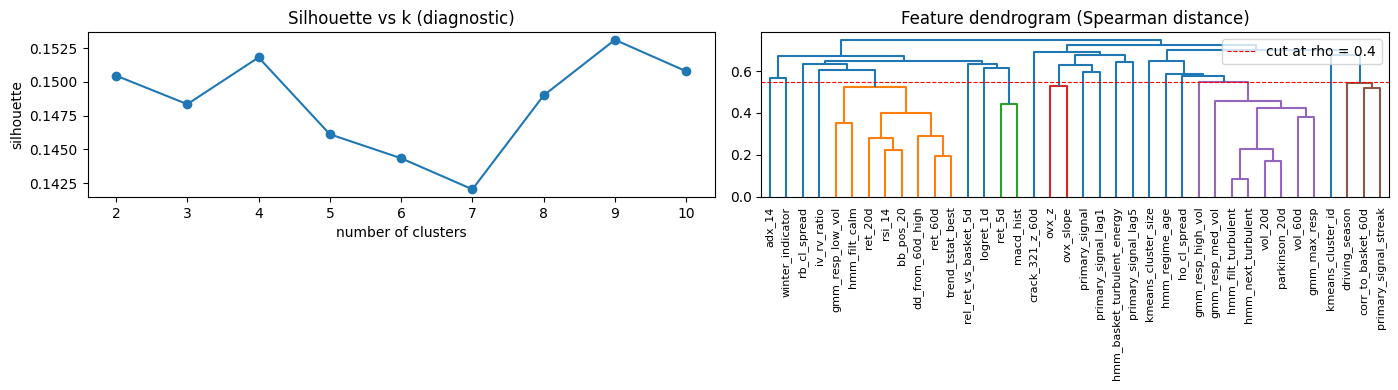

In [13]:
# Cluster the features by their correlation, on the training window only (no leakage).
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score

# keep only features that actually vary in the training window
cluster_feats = [c for c in X_train.columns if X_train[c].std() > 0]

# Spearman correlation -> Lopez de Prado distance d = sqrt(0.5 (1 - rho))
corr = X_train[cluster_feats].corr(method='spearman')
dist = np.sqrt(0.5 * (1 - corr)).clip(lower=0)
Z = linkage(squareform(dist.values, checks=False), method='average')

# Cut the tree at a correlation threshold, so features only share a cluster if they
# are genuinely correlated. Raise CORR_THRESHOLD for tighter, more numerous groups,
# lower it for fewer, broader ones.
CORR_THRESHOLD = 0.4
dist_cut = np.sqrt(0.5 * (1 - CORR_THRESHOLD))
cluster_id = pd.Series(fcluster(Z, dist_cut, criterion='distance'),
                       index=cluster_feats, name='cluster')
print(f'CORR_THRESHOLD = {CORR_THRESHOLD}  ->  {cluster_id.nunique()} clusters')

# Silhouette curve, kept only as a diagnostic. A flat curve means there is no single best k.
sil = {}
for k in range(2, min(11, len(cluster_feats))):
    labels_k = fcluster(Z, k, criterion='maxclust')
    if len(np.unique(labels_k)) < 2:
        continue
    sil[k] = silhouette_score(dist.values, labels_k, metric='precomputed')

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(list(sil.keys()), list(sil.values()), marker='o')
ax[0].set_xlabel('number of clusters')
ax[0].set_ylabel('silhouette')
ax[0].set_title('Silhouette vs k (diagnostic)')
dendrogram(Z, labels=cluster_feats, ax=ax[1], leaf_rotation=90, color_threshold=dist_cut)
ax[1].axhline(dist_cut, color='red', ls='--', lw=0.8, label=f'cut at rho = {CORR_THRESHOLD}')
ax[1].legend()
ax[1].set_title('Feature dendrogram (Spearman distance)')
plt.tight_layout()
plt.show()

### 7.2 Cluster Composition and Names

We list the features in each cluster and attach a readable name from the dominant theme of its members, for example volatility, momentum, energy spreads or implied vol. The names are only a suggestion, the `cluster_names` dictionary can be edited if a label does not fit. These names carry through to the factor columns and to the cluster-level importance analysis later on.

In [14]:
# Show the members of each cluster and auto-suggest a readable name from the dominant theme.
THEME = {
    'logret_1d': 'returns', 'ret_5d': 'returns', 'ret_20d': 'returns', 'ret_60d': 'returns',
    'vol_20d': 'volatility', 'vol_60d': 'volatility', 'parkinson_20d': 'volatility', 'vol_of_vol_20d': 'volatility',
    'rsi_14': 'oscillators', 'macd_hist': 'oscillators', 'bb_pos_20': 'oscillators',
    'adx_14': 'trend', 'trend_tstat_best': 'trend', 'dd_from_60d_high': 'drawdown',
    'crack_321_z_60d': 'energy_spreads', 'ho_cl_spread': 'energy_spreads', 'rb_cl_spread': 'energy_spreads',
    'rel_ret_vs_basket_5d': 'cross_sectional', 'corr_to_basket_60d': 'cross_sectional',
    'winter_indicator': 'seasonality', 'driving_season': 'seasonality',
    'ovx_z': 'implied_vol', 'iv_rv_ratio': 'implied_vol', 'ovx_slope': 'implied_vol',
    'gmm_resp_low_vol': 'regime', 'gmm_resp_med_vol': 'regime', 'gmm_resp_high_vol': 'regime', 'gmm_max_resp': 'regime',
    'hmm_filt_calm': 'regime', 'hmm_filt_turbulent': 'regime', 'hmm_next_turbulent': 'regime',
    'hmm_regime_age': 'regime', 'hmm_basket_turbulent_energy': 'regime',
    'kmeans_cluster_id': 'regime', 'kmeans_cluster_size': 'regime',
    'primary_signal': 'signal', 'primary_signal_lag1': 'signal', 'primary_signal_lag5': 'signal', 'primary_signal_streak': 'signal',
}

cluster_names, used = {}, {}
for c in sorted(cluster_id.unique()):
    members = list(cluster_id[cluster_id == c].index)
    themes = pd.Series([THEME.get(m, 'other') for m in members]).value_counts()
    name = themes.index[0]
    if len(themes) > 1 and themes.iloc[1] == themes.iloc[0]:
        name = f'{themes.index[0]}_{themes.index[1]}'   # tie, combine the top two themes
    used[name] = used.get(name, 0) + 1
    if used[name] > 1:
        name = f'{name}_{used[name]}'                    # keep the names unique
    cluster_names[c] = name
    print(f'cluster {c:>2}  ->  {name:<22} {members}')

# Edit cluster_names here if any auto-suggested label does not fit.

cluster  1  ->  trend                  ['adx_14']
cluster  2  ->  seasonality            ['winter_indicator']
cluster  3  ->  returns_oscillators    ['ret_20d', 'ret_60d', 'rsi_14', 'bb_pos_20', 'dd_from_60d_high', 'trend_tstat_best', 'gmm_resp_low_vol', 'hmm_filt_calm']
cluster  4  ->  implied_vol            ['iv_rv_ratio']
cluster  5  ->  energy_spreads         ['rb_cl_spread']
cluster  6  ->  returns_oscillators_2  ['ret_5d', 'macd_hist']
cluster  7  ->  returns                ['logret_1d']
cluster  8  ->  cross_sectional        ['rel_ret_vs_basket_5d']
cluster  9  ->  implied_vol_2          ['ovx_z', 'ovx_slope']
cluster 10  ->  signal                 ['primary_signal']
cluster 11  ->  signal_2               ['primary_signal_lag1']
cluster 12  ->  regime                 ['hmm_basket_turbulent_energy']
cluster 13  ->  signal_3               ['primary_signal_lag5']
cluster 14  ->  energy_spreads_2       ['crack_321_z_60d']
cluster 15  ->  regime_2               ['vol_20d', 'vol_60d',

### 7.3 Within-Cluster PC1

Each cluster is reduced to a single factor, the first principal component taken within that cluster. This keeps the denoising benefit of PCA but ties every factor to one named group, so we can still say which group drives the model. We sign-align each component to its cluster mean so a higher value has a consistent meaning, and we report how much of the cluster variance the first component captures. The scaler and the components are fit on the training window and then applied to the test window.

**Why a RobustScaler.** Everywhere we standardise features in this notebook (before the within-cluster PCA here, and again for the logistic-regression and neural-network inputs in Section 9) we use a `RobustScaler` (centre on the median, scale by the interquartile range) rather than a `StandardScaler`. Heating oil returns are fat-tailed and event-driven, so a few extreme sessions would inflate the standard deviation and squash the rest of the distribution, whereas the median and IQR are barely moved by those outliers. The bulk of the data is therefore scaled consistently and no single shock day dominates the PCA or the model inputs.

In [15]:
# Reduce each cluster to a single factor, the first principal component within that cluster.
# The scaler, the clustering and the sign alignment are all fit on the training window only.
scaler = RobustScaler()
Xtr_s = pd.DataFrame(scaler.fit_transform(X_train[cluster_feats]), index=X_train.index, columns=cluster_feats)
Xte_s = pd.DataFrame(scaler.transform(X_test[cluster_feats]),      index=X_test.index,  columns=cluster_feats)

cluster_pca, evr, train_fac, test_fac = {}, {}, {}, {}
for c in sorted(cluster_id.unique()):
    members = list(cluster_id[cluster_id == c].index)
    p = PCA(n_components=1, random_state=42)
    tr = p.fit_transform(Xtr_s[members]).ravel()
    te = p.transform(Xte_s[members]).ravel()
    if np.corrcoef(tr, Xtr_s[members].mean(axis=1))[0, 1] < 0:   # sign-align to the cluster mean
        tr, te = -tr, -te
    name = cluster_names[c]
    train_fac[name], test_fac[name] = tr, te
    evr[name] = p.explained_variance_ratio_[0]
    cluster_pca[c] = p

train_pca_df = pd.DataFrame(train_fac, index=X_train.index)
test_pca_df  = pd.DataFrame(test_fac,  index=X_test.index)
X_train_pca, X_test_pca = train_pca_df.values, test_pca_df.values
pc_cols = list(train_pca_df.columns)

print('cluster factors:', pc_cols)
print('PC1 variance explained per cluster:', {k: round(v, 2) for k, v in evr.items()})
print(f'reduced from {len(cluster_feats)} features to {len(pc_cols)} cluster factors')
train_pca_df.head()

cluster factors: ['trend', 'seasonality', 'returns_oscillators', 'implied_vol', 'energy_spreads', 'returns_oscillators_2', 'returns', 'cross_sectional', 'implied_vol_2', 'signal', 'signal_2', 'regime', 'signal_3', 'energy_spreads_2', 'regime_2', 'energy_spreads_3', 'regime_3', 'regime_4', 'cross_sectional_seasonality', 'regime_5']
PC1 variance explained per cluster: {'trend': np.float64(1.0), 'seasonality': np.float64(1.0), 'returns_oscillators': np.float64(0.73), 'implied_vol': np.float64(1.0), 'energy_spreads': np.float64(1.0), 'returns_oscillators_2': np.float64(0.82), 'returns': np.float64(1.0), 'cross_sectional': np.float64(1.0), 'implied_vol_2': np.float64(0.88), 'signal': np.float64(1.0), 'signal_2': np.float64(1.0), 'regime': np.float64(1.0), 'signal_3': np.float64(1.0), 'energy_spreads_2': np.float64(1.0), 'regime_2': np.float64(1.0), 'energy_spreads_3': np.float64(1.0), 'regime_3': np.float64(1.0), 'regime_4': np.float64(1.0), 'cross_sectional_seasonality': np.float64(0.69), 

,trend,seasonality,returns_oscillators,implied_vol,energy_spreads,returns_oscillators_2,returns,cross_sectional,implied_vol_2,signal,signal_2,regime,signal_3,energy_spreads_2,regime_2,energy_spreads_3,regime_3,regime_4,cross_sectional_seasonality,regime_5
date,,,,,,,,,,,,,,,,,,,,
2020-01-13,-0.013937,0.715711,0.076489,0.374895,-1.048205,-1.637020,-0.406658,-0.966992,0.291699,-0.049875,-0.049875,0.575557,-0.049875,1.061484,-96.069952,-2.183404,0.499537,0.582294,-0.907142,-0.466334
2020-01-14,-0.032029,0.715711,-0.192716,0.287833,-0.906933,-1.849464,-0.581330,-0.726748,0.254017,-0.049875,-0.049875,0.575452,-0.049875,1.300903,-96.085320,-2.172994,0.528108,0.582294,-0.839628,-0.466334
2020-01-15,-0.065789,0.715711,-0.225778,0.412517,-0.947701,-1.779320,0.249286,-0.697572,0.062890,-0.049875,-0.049875,0.575741,-0.049875,-0.139561,-95.982841,-2.092832,0.556680,0.582294,-0.831663,-0.466334
2020-01-16,-0.113059,0.715711,-0.478849,0.084142,-0.980273,-1.574013,-0.626531,-0.651725,-0.838385,-0.049875,-0.049875,0.575117,-0.049875,-0.612688,-96.003798,-2.296756,0.585251,0.082294,-0.790668,-0.466334
2020-01-17,-0.191069,0.715711,-0.641682,0.114166,-0.988951,-1.705820,-0.346735,-0.697751,-0.650579,-0.049875,-0.049875,0.575723,-0.049875,-0.857445,-95.772522,-2.739610,0.613823,-0.417706,-0.766199,-0.466334


### 7.4 HMM Regime Filtering

We choose the number of hidden states with a BIC sweep, fitting candidate models with 2 to 5 states and several random seeds and keeping the lowest BIC. We then run the forward algorithm by hand to obtain filtering posteriors on the cluster factors. Filtering uses only past and present data, unlike the smoothing that `predict_proba` would apply, so the regime probabilities that feed the meta-model stay free of look-ahead. We also compute a one-step-ahead forecast by pushing the current filtered state through the transition matrix.

In [16]:
# BIC sweep for the optimal number of HMM states, capped at 5

def hmm_bic(model, X):
    K = model.n_components
    T, d = X.shape
    logL = model.score(X)
    k_params = (K - 1) + K * (K - 1) + K * (2 * d)
    return -2 * logL + k_params * np.log(T), logL

best = {'bic': np.inf, 'hmm': None, 'K': None}
for K in range(2, 6):
    best_for_K = {'bic': np.inf, 'hmm': None}
    for seed in range(10):
        h = GaussianHMM(n_components=K, covariance_type='diag',
                        n_iter=1000, random_state=42 + seed)
        try:
            h.fit(X_train_pca)
            bic, _ = hmm_bic(h, X_train_pca)
            if bic < best_for_K['bic']:
                best_for_K = {'bic': bic, 'hmm': h}
        except Exception:
            continue
    print(f'K={K}: BIC={best_for_K["bic"]:,.1f}')
    if best_for_K['bic'] < best['bic']:
        best = {'bic': best_for_K['bic'], 'hmm': best_for_K['hmm'], 'K': K}

print('Chosen K =', best['K'])

Model is not converging.  Current: -8188.589719624457 is not greater than -8188.5759910612605. Delta is -0.013728563196309551


Model is not converging.  Current: -8188.593518929334 is not greater than -8188.5767600968475. Delta is -0.016758832486630126


K=2: BIC=16,874.7


Model is not converging.  Current: -7270.392009268763 is not greater than -7270.384787662317. Delta is -0.0072216064463646035


Model is not converging.  Current: -7271.940941042956 is not greater than -7271.935779832852. Delta is -0.00516121010423376


...

Model is not converging.  Current: -5676.644581458464 is not greater than -5676.60594946314. Delta is -0.03863199532406725


K=4: BIC=11,131.8


Model is not converging.  Current: -6339.271637553269 is not greater than -6339.271580997289. Delta is -5.6555980336270295e-05


Model is not converging.  Current: -4953.437882813464 is not greater than -4953.434282698501. Delta is -0.003600114962864609


K=5: BIC=9,010.4
Chosen K = 5


In [17]:
# IMPORTANT: predict_proba runs forward-backward (smoothing) which uses future
# data inside the train window. For meta-model features we want filtering only.
# Below: filtering posteriors via the forward algorithm.

def hmm_filter(model, X):
    """Forward-only filtering posterior - no future leakage."""
    T = len(X)
    K = model.n_components
    log_alpha = np.empty((T, K))
    # initial
    log_alpha[0] = np.log(model.startprob_ + 1e-300) + model._compute_log_likelihood(X[:1])[0]
    log_trans = np.log(model.transmat_ + 1e-300)
    log_obs = model._compute_log_likelihood(X)
    for t in range(1, T):
        # log_alpha[t,k] = logsumexp_j(log_alpha[t-1,j] + log_trans[j,k]) + log_obs[t,k]
        m = log_alpha[t-1, :, None] + log_trans   # (K, K)
        log_alpha[t] = log_obs[t] + (m.max(axis=0) +
                                     np.log(np.exp(m - m.max(axis=0)).sum(axis=0)))
    # normalise to get posteriors
    log_alpha -= log_alpha.max(axis=1, keepdims=True)
    a = np.exp(log_alpha)
    return a / a.sum(axis=1, keepdims=True)

train_post = hmm_filter(best['hmm'], X_train_pca)
test_post  = hmm_filter(best['hmm'], X_test_pca)

for i in range(best['K']):
    train_pca_df[f'hmm_filt_{i}'] = train_post[:, i]
    test_pca_df[f'hmm_filt_{i}']  = test_post[:, i]

train_pca_df.head()

,trend,seasonality,returns_oscillators,implied_vol,energy_spreads,returns_oscillators_2,returns,cross_sectional,implied_vol_2,signal,...,energy_spreads_3,regime_3,regime_4,cross_sectional_seasonality,regime_5,hmm_filt_0,hmm_filt_1,hmm_filt_2,hmm_filt_3,hmm_filt_4
date,,,,,,,,,,,,,,,,,,,,,
2020-01-13,-0.013937,0.715711,0.076489,0.374895,-1.048205,-1.637020,-0.406658,-0.966992,0.291699,-0.049875,...,-2.183404,0.499537,0.582294,-0.907142,-0.466334,1.000000,0.0,0.0,1.009919e-21,0.0
2020-01-14,-0.032029,0.715711,-0.192716,0.287833,-0.906933,-1.849464,-0.581330,-0.726748,0.254017,-0.049875,...,-2.172994,0.528108,0.582294,-0.839628,-0.466334,0.000983,0.0,0.0,9.990165e-01,0.0
2020-01-15,-0.065789,0.715711,-0.225778,0.412517,-0.947701,-1.779320,0.249286,-0.697572,0.062890,-0.049875,...,-2.092832,0.556680,0.582294,-0.831663,-0.466334,0.000022,0.0,0.0,9.999784e-01,0.0
2020-01-16,-0.113059,0.715711,-0.478849,0.084142,-0.980273,-1.574013,-0.626531,-0.651725,-0.838385,-0.049875,...,-2.296756,0.585251,0.082294,-0.790668,-0.466334,0.000025,0.0,0.0,9.999754e-01,0.0
2020-01-17,-0.191069,0.715711,-0.641682,0.114166,-0.988951,-1.705820,-0.346735,-0.697751,-0.650579,-0.049875,...,-2.739610,0.613823,-0.417706,-0.766199,-0.466334,0.000113,0.0,0.0,9.998872e-01,0.0


## 8. Triple-Barrier Meta-Labels

We label each primary signal with the triple-barrier method. A trade counts as a win if the profit-taking barrier is reached before the stop-loss or the time limit. These labels become the target the meta-model learns to predict for heating oil.

**Why these barrier choices make sense for heating oil**

**Volatility scaling with EWM span 20:** The daily vol estimate uses a 20-day exponentially weighted standard deviation of log returns, and the exponential weighting is deliberate. The heating oil market is event-driven. A surprise EIA inventory print, a cold-weather forecast, or a sharp move in crude can lift realised vol quickly. A simple rolling standard deviation treats every observation equally, so a spike three weeks ago carries the same weight as yesterday, whereas the EWM decays older observations so the vol estimate at trade entry reflects the current regime rather than a stale average. The 20-day span sits at roughly one trading month, long enough to avoid noise from a single session but short enough to adapt within a few weeks when the regime genuinely shifts.

**Symmetric barriers at pt_sl = [1.5, 1.5]:** The symmetry is intentional, it means the label is not pre-tilted toward wins or losses by construction. If the profit-take were wider than the stop-loss, the win rate would be inflated and the meta-label distribution would be harder to interpret. The 1.5 multiplier reflects heating oil's return distribution, which has fat tails and persistent ranges. A multiplier of 1.0 would set barriers just one standard deviation from entry, which gets hit constantly by noise rather than genuine directional moves, while a multiplier of 2.0 or higher would push too many trades to the time barrier and degrade label quality.

**Maximum hold of 20 days:** Twenty trading days is one calendar month, which is the right horizon for a trend-following signal on an energy instrument. Signals based on regime state, energy spreads, and trend-scanning t-statistics pick up moves that play out over days to weeks, not hours, so a 5-day hold is too short for them to resolve. A 60-day hold would introduce roll risk and force the model to hold through multiple EIA reports, swings in crude, and seasonal demand transitions, all of which can reverse the original signal rationale. The EIA weekly petroleum status report lands every Wednesday, so 20 trading days covers roughly four report cycles. A signal that has not resolved after four of those cycles has probably lost its original context. A shorter hold would also push more labels to the time barrier, producing ambiguous outcomes for trades that were neither right nor wrong, so 20 days gives a reasonable fraction of clean barrier touches, which is what a well-calibrated meta-label dataset needs.

## 7. Dimensionality Reduction and Regime Filtering

Here we handle the downstream steps. We split the data at the signal start date, group the correlated features into clusters, reduce each cluster to a single factor with a within-cluster principal component, add the forward-only HMM regime probabilities, and pass the result to the models. The aim is to cut the feature count down to a small set of interpretable factors so the model stays stable on a small sample and we can still say which feature group drives it.

**Why clustering rather than a single global PCA**

With many more candidate features than labelled rows, some dimensionality control is needed or the model overfits. A global PCA would do that, but it rotates every feature into dense components, so the inputs stop being interpretable and the leading components can be dominated by whichever block of features happens to carry the most variance. Grouping correlated features and taking one principal component within each group gives the same denoising and an even smaller feature count, while keeping every factor tied to a named theme. That interpretability is exactly what the cluster-level importance analysis later in the project depends on.

**Filtering over smoothing**

The HMM that runs on these factors uses the forward algorithm only. The forward-backward algorithm that standard implementations use for `predict_proba` is a smoother, so the probability assigned to time `t` depends on observations both before and after `t`. That is fine for offline analysis but fatal for a trading model, since it means today's regime label was partly determined by tomorrow's returns. Using the forward pass only means the regime probabilities are genuine real-time estimates.

**Why a 70/30 train/test split**

The split is reserved purely for final evaluation, the test set is never touched during tuning. The primary signal data begins in 2020, but the feature pipeline has a 504-day warmup before the first GMM, HMM, and PCA refit fires, which consumes roughly two years before a single fully-featured labelled observation is available. That is why `SIGNAL_START = '2021-08-16'` sits where it does, and a 70/30 split on that effective window gives roughly two years of training and just under one year of test data. Triple-barrier labelling shrinks the sample further, since it only fires when the primary signal is non-zero and many entries hit the time barrier, so going to 80/20 would push the test set down to a point where the standard error of AUC is nearly as wide as the signal itself. The 5-fold walk-forward CV on the training set does the heavy lifting for model selection, and a 70% training allocation gives each fold enough data to produce a meaningful AUC estimate.

The honest limitation is that a single temporal split means the test set covers one specific market period. If that period happens to be unusually calm or unusually stressed, the test AUC will not reflect long-run performance. The right way to read the results is as how the meta-model would have performed had it gone live at the split date, not as a claim about universal performance.

In [18]:
SIGNAL_START = '2021-08-16'

# Feature set fed into the clustering and the downstream models.
# Base and energy features, plus OVX, plus the Tier 3 latent and Tier 4 signal features.
downstream_cols = [
    'logret_1d', 'vol_20d', 'vol_60d', 'parkinson_20d',
    'ret_5d', 'ret_20d', 'ret_60d',
    'rsi_14', 'macd_hist', 'bb_pos_20', 'adx_14',
    'dd_from_60d_high', 'trend_tstat_best',
    'crack_321_z_60d', 'ho_cl_spread', 'rb_cl_spread',
    'rel_ret_vs_basket_5d', 'corr_to_basket_60d',
    'winter_indicator', 'driving_season',
]

# Add OVX columns if they were loaded in section 4.1
ovx_cols = [c for c in ['ovx_z', 'iv_rv_ratio', 'ovx_slope'] if c in heating_oil.columns]
if ovx_cols:
    downstream_cols += ovx_cols
    print('Including OVX features:', ovx_cols)

# Add the Tier 3 latent regime features and the Tier 4 primary-signal features.
downstream_cols += [c for c in latent_cols + sig_cols if c in heating_oil.columns]

X = heating_oil[downstream_cols].dropna()

X_train = X.loc[X.index <  SIGNAL_START]
X_test  = X.loc[X.index >= SIGNAL_START]

print('train:', X_train.shape, 'test:', X_test.shape, '| features:', len(downstream_cols))

Including OVX features: ['ovx_z', 'iv_rv_ratio', 'ovx_slope']
train: (401, 38) test: (221, 38) | features: 38


### 7.1 Feature Clustering

Instead of one PCA over the whole feature set, we group the features by how correlated they are, so each group can later be summarised and interrogated as a unit. We measure similarity with the Spearman correlation, which is robust to the fat tails in return data, and convert it to the Lopez de Prado distance `d = sqrt(0.5 (1 - rho))`, which is a proper metric. We then run average-linkage hierarchical clustering and cut the tree at a correlation threshold, so two features only share a cluster if they are genuinely correlated.

The silhouette curve here is flat, which tells us there is no single best number of clusters, so picking a fixed k would force unrelated features together and leave clusters that one principal component cannot summarise well. Cutting at a correlation level instead respects the real structure and keeps every cluster tight, so its first principal component stays a faithful summary. `CORR_THRESHOLD` is the one knob, raise it for tighter and more numerous groups, lower it for fewer and broader ones. Everything here is fit on the training window only, and the silhouette curve and dendrogram are shown as diagnostics.

CORR_THRESHOLD = 0.4  ->  20 clusters


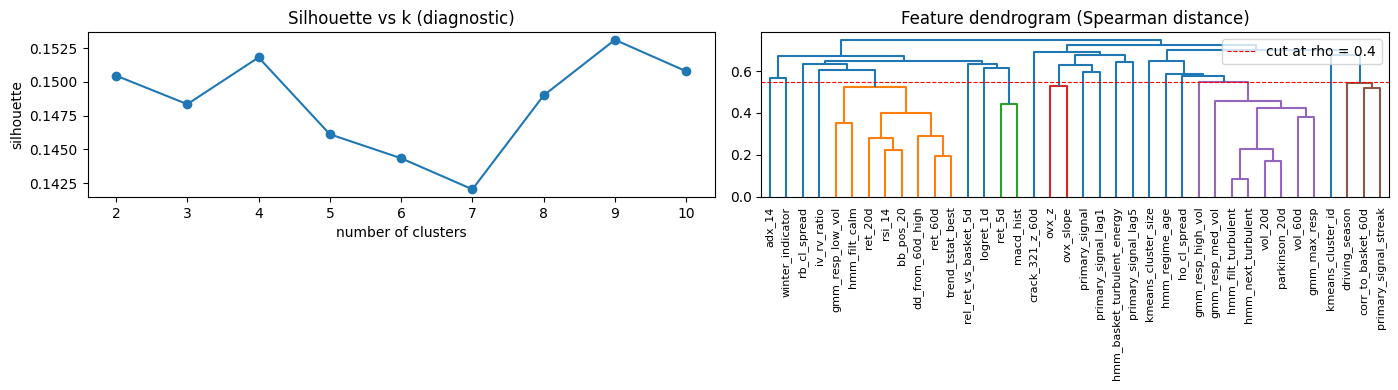

In [19]:
# Cluster the features by their correlation, on the training window only (no leakage).
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score

# keep only features that actually vary in the training window
cluster_feats = [c for c in X_train.columns if X_train[c].std() > 0]

# Spearman correlation -> Lopez de Prado distance d = sqrt(0.5 (1 - rho))
corr = X_train[cluster_feats].corr(method='spearman')
dist = np.sqrt(0.5 * (1 - corr)).clip(lower=0)
Z = linkage(squareform(dist.values, checks=False), method='average')

# Cut the tree at a correlation threshold, so features only share a cluster if they
# are genuinely correlated. Raise CORR_THRESHOLD for tighter, more numerous groups,
# lower it for fewer, broader ones.
CORR_THRESHOLD = 0.4
dist_cut = np.sqrt(0.5 * (1 - CORR_THRESHOLD))
cluster_id = pd.Series(fcluster(Z, dist_cut, criterion='distance'),
                       index=cluster_feats, name='cluster')
print(f'CORR_THRESHOLD = {CORR_THRESHOLD}  ->  {cluster_id.nunique()} clusters')

# Silhouette curve, kept only as a diagnostic. A flat curve means there is no single best k.
sil = {}
for k in range(2, min(11, len(cluster_feats))):
    labels_k = fcluster(Z, k, criterion='maxclust')
    if len(np.unique(labels_k)) < 2:
        continue
    sil[k] = silhouette_score(dist.values, labels_k, metric='precomputed')

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(list(sil.keys()), list(sil.values()), marker='o')
ax[0].set_xlabel('number of clusters')
ax[0].set_ylabel('silhouette')
ax[0].set_title('Silhouette vs k (diagnostic)')
dendrogram(Z, labels=cluster_feats, ax=ax[1], leaf_rotation=90, color_threshold=dist_cut)
ax[1].axhline(dist_cut, color='red', ls='--', lw=0.8, label=f'cut at rho = {CORR_THRESHOLD}')
ax[1].legend()
ax[1].set_title('Feature dendrogram (Spearman distance)')
plt.tight_layout()
plt.show()

### 7.2 Cluster Composition and Names

We list the features in each cluster and attach a readable name from the dominant theme of its members, for example volatility, momentum, energy spreads or implied vol. The names are only a suggestion, the `cluster_names` dictionary can be edited if a label does not fit. These names carry through to the factor columns and to the cluster-level importance analysis later on.

In [20]:
# Show the members of each cluster and auto-suggest a readable name from the dominant theme.
THEME = {
    'logret_1d': 'returns', 'ret_5d': 'returns', 'ret_20d': 'returns', 'ret_60d': 'returns',
    'vol_20d': 'volatility', 'vol_60d': 'volatility', 'parkinson_20d': 'volatility', 'vol_of_vol_20d': 'volatility',
    'rsi_14': 'oscillators', 'macd_hist': 'oscillators', 'bb_pos_20': 'oscillators',
    'adx_14': 'trend', 'trend_tstat_best': 'trend', 'dd_from_60d_high': 'drawdown',
    'crack_321_z_60d': 'energy_spreads', 'ho_cl_spread': 'energy_spreads', 'rb_cl_spread': 'energy_spreads',
    'rel_ret_vs_basket_5d': 'cross_sectional', 'corr_to_basket_60d': 'cross_sectional',
    'winter_indicator': 'seasonality', 'driving_season': 'seasonality',
    'ovx_z': 'implied_vol', 'iv_rv_ratio': 'implied_vol', 'ovx_slope': 'implied_vol',
    'gmm_resp_low_vol': 'regime', 'gmm_resp_med_vol': 'regime', 'gmm_resp_high_vol': 'regime', 'gmm_max_resp': 'regime',
    'hmm_filt_calm': 'regime', 'hmm_filt_turbulent': 'regime', 'hmm_next_turbulent': 'regime',
    'hmm_regime_age': 'regime', 'hmm_basket_turbulent_energy': 'regime',
    'kmeans_cluster_id': 'regime', 'kmeans_cluster_size': 'regime',
    'primary_signal': 'signal', 'primary_signal_lag1': 'signal', 'primary_signal_lag5': 'signal', 'primary_signal_streak': 'signal',
}

cluster_names, used = {}, {}
for c in sorted(cluster_id.unique()):
    members = list(cluster_id[cluster_id == c].index)
    themes = pd.Series([THEME.get(m, 'other') for m in members]).value_counts()
    name = themes.index[0]
    if len(themes) > 1 and themes.iloc[1] == themes.iloc[0]:
        name = f'{themes.index[0]}_{themes.index[1]}'   # tie, combine the top two themes
    used[name] = used.get(name, 0) + 1
    if used[name] > 1:
        name = f'{name}_{used[name]}'                    # keep the names unique
    cluster_names[c] = name
    print(f'cluster {c:>2}  ->  {name:<22} {members}')

# Edit cluster_names here if any auto-suggested label does not fit.

cluster  1  ->  trend                  ['adx_14']
cluster  2  ->  seasonality            ['winter_indicator']
cluster  3  ->  returns_oscillators    ['ret_20d', 'ret_60d', 'rsi_14', 'bb_pos_20', 'dd_from_60d_high', 'trend_tstat_best', 'gmm_resp_low_vol', 'hmm_filt_calm']
cluster  4  ->  implied_vol            ['iv_rv_ratio']
cluster  5  ->  energy_spreads         ['rb_cl_spread']
cluster  6  ->  returns_oscillators_2  ['ret_5d', 'macd_hist']
cluster  7  ->  returns                ['logret_1d']
cluster  8  ->  cross_sectional        ['rel_ret_vs_basket_5d']
cluster  9  ->  implied_vol_2          ['ovx_z', 'ovx_slope']
cluster 10  ->  signal                 ['primary_signal']
cluster 11  ->  signal_2               ['primary_signal_lag1']
cluster 12  ->  regime                 ['hmm_basket_turbulent_energy']
cluster 13  ->  signal_3               ['primary_signal_lag5']
cluster 14  ->  energy_spreads_2       ['crack_321_z_60d']
cluster 15  ->  regime_2               ['vol_20d', 'vol_60d',

### 7.3 Within-Cluster PC1

Each cluster is reduced to a single factor, the first principal component taken within that cluster. This keeps the denoising benefit of PCA but ties every factor to one named group, so we can still say which group drives the model. We sign-align each component to its cluster mean so a higher value has a consistent meaning, and we report how much of the cluster variance the first component captures. The scaler and the components are fit on the training window and then applied to the test window.

In [21]:
# Reduce each cluster to a single factor, the first principal component within that cluster.
# The scaler, the clustering and the sign alignment are all fit on the training window only.
scaler = RobustScaler()
Xtr_s = pd.DataFrame(scaler.fit_transform(X_train[cluster_feats]), index=X_train.index, columns=cluster_feats)
Xte_s = pd.DataFrame(scaler.transform(X_test[cluster_feats]),      index=X_test.index,  columns=cluster_feats)

cluster_pca, evr, train_fac, test_fac = {}, {}, {}, {}
for c in sorted(cluster_id.unique()):
    members = list(cluster_id[cluster_id == c].index)
    p = PCA(n_components=1, random_state=42)
    tr = p.fit_transform(Xtr_s[members]).ravel()
    te = p.transform(Xte_s[members]).ravel()
    if np.corrcoef(tr, Xtr_s[members].mean(axis=1))[0, 1] < 0:   # sign-align to the cluster mean
        tr, te = -tr, -te
    name = cluster_names[c]
    train_fac[name], test_fac[name] = tr, te
    evr[name] = p.explained_variance_ratio_[0]
    cluster_pca[c] = p

train_pca_df = pd.DataFrame(train_fac, index=X_train.index)
test_pca_df  = pd.DataFrame(test_fac,  index=X_test.index)
X_train_pca, X_test_pca = train_pca_df.values, test_pca_df.values
pc_cols = list(train_pca_df.columns)

print('cluster factors:', pc_cols)
print('PC1 variance explained per cluster:', {k: round(v, 2) for k, v in evr.items()})
print(f'reduced from {len(cluster_feats)} features to {len(pc_cols)} cluster factors')
train_pca_df.head()

cluster factors: ['trend', 'seasonality', 'returns_oscillators', 'implied_vol', 'energy_spreads', 'returns_oscillators_2', 'returns', 'cross_sectional', 'implied_vol_2', 'signal', 'signal_2', 'regime', 'signal_3', 'energy_spreads_2', 'regime_2', 'energy_spreads_3', 'regime_3', 'regime_4', 'cross_sectional_seasonality', 'regime_5']
PC1 variance explained per cluster: {'trend': np.float64(1.0), 'seasonality': np.float64(1.0), 'returns_oscillators': np.float64(0.73), 'implied_vol': np.float64(1.0), 'energy_spreads': np.float64(1.0), 'returns_oscillators_2': np.float64(0.82), 'returns': np.float64(1.0), 'cross_sectional': np.float64(1.0), 'implied_vol_2': np.float64(0.88), 'signal': np.float64(1.0), 'signal_2': np.float64(1.0), 'regime': np.float64(1.0), 'signal_3': np.float64(1.0), 'energy_spreads_2': np.float64(1.0), 'regime_2': np.float64(1.0), 'energy_spreads_3': np.float64(1.0), 'regime_3': np.float64(1.0), 'regime_4': np.float64(1.0), 'cross_sectional_seasonality': np.float64(0.69), 

,trend,seasonality,returns_oscillators,implied_vol,energy_spreads,returns_oscillators_2,returns,cross_sectional,implied_vol_2,signal,signal_2,regime,signal_3,energy_spreads_2,regime_2,energy_spreads_3,regime_3,regime_4,cross_sectional_seasonality,regime_5
date,,,,,,,,,,,,,,,,,,,,
2020-01-13,-0.013937,0.715711,0.076489,0.374895,-1.048205,-1.637020,-0.406658,-0.966992,0.291699,-0.049875,-0.049875,0.575557,-0.049875,1.061484,-96.069952,-2.183404,0.499537,0.582294,-0.907142,-0.466334
2020-01-14,-0.032029,0.715711,-0.192716,0.287833,-0.906933,-1.849464,-0.581330,-0.726748,0.254017,-0.049875,-0.049875,0.575452,-0.049875,1.300903,-96.085320,-2.172994,0.528108,0.582294,-0.839628,-0.466334
2020-01-15,-0.065789,0.715711,-0.225778,0.412517,-0.947701,-1.779320,0.249286,-0.697572,0.062890,-0.049875,-0.049875,0.575741,-0.049875,-0.139561,-95.982841,-2.092832,0.556680,0.582294,-0.831663,-0.466334
2020-01-16,-0.113059,0.715711,-0.478849,0.084142,-0.980273,-1.574013,-0.626531,-0.651725,-0.838385,-0.049875,-0.049875,0.575117,-0.049875,-0.612688,-96.003798,-2.296756,0.585251,0.082294,-0.790668,-0.466334
2020-01-17,-0.191069,0.715711,-0.641682,0.114166,-0.988951,-1.705820,-0.346735,-0.697751,-0.650579,-0.049875,-0.049875,0.575723,-0.049875,-0.857445,-95.772522,-2.739610,0.613823,-0.417706,-0.766199,-0.466334


### 7.4 HMM Regime Filtering

We choose the number of hidden states with a BIC sweep, fitting candidate models with 2 to 5 states and several random seeds and keeping the lowest BIC. We then run the forward algorithm by hand to obtain filtering posteriors on the cluster factors. Filtering uses only past and present data, unlike the smoothing that `predict_proba` would apply, so the regime probabilities that feed the meta-model stay free of look-ahead. We also compute a one-step-ahead forecast by pushing the current filtered state through the transition matrix.

In [22]:
# BIC sweep for the optimal number of HMM states, capped at 5

def hmm_bic(model, X):
    K = model.n_components
    T, d = X.shape
    logL = model.score(X)
    k_params = (K - 1) + K * (K - 1) + K * (2 * d)
    return -2 * logL + k_params * np.log(T), logL

best = {'bic': np.inf, 'hmm': None, 'K': None}
for K in range(2, 6):
    best_for_K = {'bic': np.inf, 'hmm': None}
    for seed in range(10):
        h = GaussianHMM(n_components=K, covariance_type='diag',
                        n_iter=1000, random_state=42 + seed)
        try:
            h.fit(X_train_pca)
            bic, _ = hmm_bic(h, X_train_pca)
            if bic < best_for_K['bic']:
                best_for_K = {'bic': bic, 'hmm': h}
        except Exception:
            continue
    print(f'K={K}: BIC={best_for_K["bic"]:,.1f}')
    if best_for_K['bic'] < best['bic']:
        best = {'bic': best_for_K['bic'], 'hmm': best_for_K['hmm'], 'K': K}

print('Chosen K =', best['K'])

Model is not converging.  Current: -8188.589719624457 is not greater than -8188.5759910612605. Delta is -0.013728563196309551


Model is not converging.  Current: -8188.593518929334 is not greater than -8188.5767600968475. Delta is -0.016758832486630126


K=2: BIC=16,874.7


Model is not converging.  Current: -7270.392009268763 is not greater than -7270.384787662317. Delta is -0.0072216064463646035


Model is not converging.  Current: -7271.940941042956 is not greater than -7271.935779832852. Delta is -0.00516121010423376


...

Model is not converging.  Current: -5676.644581458464 is not greater than -5676.60594946314. Delta is -0.03863199532406725


K=4: BIC=11,131.8


Model is not converging.  Current: -6339.271637553269 is not greater than -6339.271580997289. Delta is -5.6555980336270295e-05


Model is not converging.  Current: -4953.437882813464 is not greater than -4953.434282698501. Delta is -0.003600114962864609


K=5: BIC=9,010.4
Chosen K = 5


In [23]:
# IMPORTANT: predict_proba runs forward-backward (smoothing) which uses future
# data inside the train window. For meta-model features we want filtering only.
# Below: filtering posteriors via the forward algorithm.

def hmm_filter(model, X):
    """Forward-only filtering posterior - no future leakage."""
    T = len(X)
    K = model.n_components
    log_alpha = np.empty((T, K))
    # initial
    log_alpha[0] = np.log(model.startprob_ + 1e-300) + model._compute_log_likelihood(X[:1])[0]
    log_trans = np.log(model.transmat_ + 1e-300)
    log_obs = model._compute_log_likelihood(X)
    for t in range(1, T):
        # log_alpha[t,k] = logsumexp_j(log_alpha[t-1,j] + log_trans[j,k]) + log_obs[t,k]
        m = log_alpha[t-1, :, None] + log_trans   # (K, K)
        log_alpha[t] = log_obs[t] + (m.max(axis=0) +
                                     np.log(np.exp(m - m.max(axis=0)).sum(axis=0)))
    # normalise to get posteriors
    log_alpha -= log_alpha.max(axis=1, keepdims=True)
    a = np.exp(log_alpha)
    return a / a.sum(axis=1, keepdims=True)

train_post = hmm_filter(best['hmm'], X_train_pca)
test_post  = hmm_filter(best['hmm'], X_test_pca)

for i in range(best['K']):
    train_pca_df[f'hmm_filt_{i}'] = train_post[:, i]
    test_pca_df[f'hmm_filt_{i}']  = test_post[:, i]

train_pca_df.head()

,trend,seasonality,returns_oscillators,implied_vol,energy_spreads,returns_oscillators_2,returns,cross_sectional,implied_vol_2,signal,...,energy_spreads_3,regime_3,regime_4,cross_sectional_seasonality,regime_5,hmm_filt_0,hmm_filt_1,hmm_filt_2,hmm_filt_3,hmm_filt_4
date,,,,,,,,,,,,,,,,,,,,,
2020-01-13,-0.013937,0.715711,0.076489,0.374895,-1.048205,-1.637020,-0.406658,-0.966992,0.291699,-0.049875,...,-2.183404,0.499537,0.582294,-0.907142,-0.466334,1.000000,0.0,0.0,1.009919e-21,0.0
2020-01-14,-0.032029,0.715711,-0.192716,0.287833,-0.906933,-1.849464,-0.581330,-0.726748,0.254017,-0.049875,...,-2.172994,0.528108,0.582294,-0.839628,-0.466334,0.000983,0.0,0.0,9.990165e-01,0.0
2020-01-15,-0.065789,0.715711,-0.225778,0.412517,-0.947701,-1.779320,0.249286,-0.697572,0.062890,-0.049875,...,-2.092832,0.556680,0.582294,-0.831663,-0.466334,0.000022,0.0,0.0,9.999784e-01,0.0
2020-01-16,-0.113059,0.715711,-0.478849,0.084142,-0.980273,-1.574013,-0.626531,-0.651725,-0.838385,-0.049875,...,-2.296756,0.585251,0.082294,-0.790668,-0.466334,0.000025,0.0,0.0,9.999754e-01,0.0
2020-01-17,-0.191069,0.715711,-0.641682,0.114166,-0.988951,-1.705820,-0.346735,-0.697751,-0.650579,-0.049875,...,-2.739610,0.613823,-0.417706,-0.766199,-0.466334,0.000113,0.0,0.0,9.998872e-01,0.0


In [24]:
def get_daily_vol(close, span=20):
    log_ret = np.log(close).diff()
    return log_ret.ewm(span=span).std()

def triple_barrier_meta_labels(close, signals, pt_sl, max_hold):
    vol = get_daily_vol(close)
    out = []
    for t0, side in signals.items():
        if pd.isna(side) or side == 0:
            continue
        if t0 not in close.index or t0 not in vol.index:
            continue
        sigma = vol.loc[t0]
        if pd.isna(sigma) or sigma <= 0:
            continue
        idx = close.index.searchsorted(t0)
        # Decoupled edge fix: tail signals with no full forward window have no
        # triple-barrier label (the path would be truncated, biasing the label
        # toward time-barrier outcomes). They still receive a prediction in the
        # export cell — predictions need only features; the label needs the path.
        # Tail counts are verified per instrument in sanity_checks.ipynb.
        if idx + max_hold >= len(close.index):
            continue
        pt =  pt_sl[0] * sigma
        sl = -pt_sl[1] * sigma
        t1 = close.index[idx + max_hold]
        entry = close.loc[t0]
        future = close.loc[t0:t1].iloc[1:]
        if future.empty:
            continue
        ret = (future / entry - 1) * side
        hit_pt = ret[ret >= pt].index.min()
        hit_sl = ret[ret <= sl].index.min()
        cand = {k: v for k, v in {'pt': hit_pt, 'sl': hit_sl, 't1': t1}.items()
                if pd.notna(v)}
        first = min(cand, key=cand.get)
        out.append({
            'entry': t0, 'exit': cand[first],
            'sigma_at_entry': sigma, 'primary_signal': side,
            'first_touch': first,
            'meta_label': 1 if first == 'pt' else 0,
        })
    return pd.DataFrame(out).set_index('entry')

# Use raw close from the OHLCV file (the parquet drops it on save)
ohlcv = pd.read_csv('../data/src/ohlcv_data.csv')
ohlcv['date'] = pd.to_datetime(ohlcv['date'])
ho_close = (
    ohlcv[ohlcv['instrument'] == 'ho1s']
    .set_index('date')['close']
    .sort_index()
)

heating_oil_signals = heating_oil['primary_signal'].dropna()
heating_oil_labels = triple_barrier_meta_labels(ho_close, heating_oil_signals, pt_sl=[1.5, 1.5], max_hold=20)
print('labels:', len(heating_oil_labels), 'win rate:', heating_oil_labels['meta_label'].mean().round(3))
heating_oil_labels.head()

labels: 62 win rate: 0.613


,exit,sigma_at_entry,primary_signal,first_touch,meta_label
entry,,,,,
2020-01-21,2020-01-23,0.012453,1.0,sl,0
2020-01-23,2020-01-24,0.011643,1.0,sl,0
2020-01-31,2020-02-03,0.016598,1.0,sl,0
2020-02-03,2020-02-05,0.016980,1.0,pt,1
2020-02-04,2020-02-05,0.016900,1.0,pt,1


**Decoupling prediction from labelling at the data edge.** The labeller above skips any signal where `idx + max_hold >= len(close.index)` — i.e. the last ~`max_hold` (20) signalled days of the available data. The triple-barrier rule needs a full forward window to be unbiased; a truncated path silently biases the label toward time-barrier (`0`) outcomes. Skipping these signals keeps training and the §11.1 evaluation honest.

Predictions are decoupled from this: the model scores rows whenever the features exist, regardless of whether the label is computable. The export cell at the end of this notebook builds its prediction matrix on **all signalled days in the deliverable window**, not just labelled ones, so the deliverable CSV has a row with a real probability for every signal — including the unlabellable tail.

This matters most on the hidden H2 2022 rerun: the labeller is data-end-aware (so the late-December tail does not pollute selection or evaluation), but predictions still cover that tail. The `sanity_checks.ipynb` notebook reports the per-instrument count of dropped tail labels and predicted-but-unlabelled days.


In [25]:
y_train = heating_oil_labels.loc[heating_oil_labels.index <  SIGNAL_START, 'meta_label']
y_test  = heating_oil_labels.loc[heating_oil_labels.index >= SIGNAL_START, 'meta_label']

X_train_heating_oil = train_pca_df.reindex(y_train.index).dropna()
X_test_heating_oil  = test_pca_df.reindex(y_test.index).dropna()
y_train = y_train.loc[X_train_heating_oil.index]
y_test  = y_test.loc[X_test_heating_oil.index]

print(X_train_heating_oil.shape, y_train.shape)
print(X_test_heating_oil.shape,  y_test.shape)

(36, 25) (36,)
(26, 25) (26,)


## 9. Models

In this section we build the meta-models with logistic regression, random forest, XGBoost, and three neural networks. We compare them with walk-forward cross-validation, which respects the time order of the data and scores each candidate by AUC across the expanding folds, then retrain the best of each on the full training set and evaluate once on the held-out test set.

In [26]:
N_SPLITS = 5

def walk_forward_cv_auc(model, X, y, n_splits=N_SPLITS):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_aucs = []
    for train_idx, test_idx in tscv.split(X.values):
        X_tr, X_te = X.values[train_idx], X.values[test_idx]
        y_tr, y_te = y.values[train_idx], y.values[test_idx]
        if len(np.unique(y_te)) < 2:
            continue
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_te)[:, 1]
        fold_aucs.append(roc_auc_score(y_te, proba))
    return {'fold_aucs': fold_aucs, 'mean_auc': np.mean(fold_aucs), 'std_auc': np.std(fold_aucs)}


### 9.1 Logistic Regression

A linear baseline. With only a few hundred labelled training observations, regularisation is the parameter that matters most, so the grid sweeps the inverse regularisation strength `C` across both L2 and L1 penalties and adds balanced class weights for the imbalanced meta-label distribution. L2 keeps every coefficient small, while L1 can zero out the least informative of the per-cluster PC1 factors, which on a small sample often generalises better because it commits to fewer signals rather than spreading weight across all of them. We avoid effectively unregularised settings, since on this sample size they overfit the CV folds and any win is likely an artefact of a favourable split.

In [27]:
# Logistic regression parameter grid

lr_param_grid = [
    {'C': 0.01,  'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 10.0,  'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l1', 'class_weight': None,       'solver': 'liblinear', 'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l1', 'class_weight': None,       'solver': 'liblinear', 'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l2', 'class_weight': 'balanced', 'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l2', 'class_weight': 'balanced', 'solver': 'lbfgs',     'max_iter': 1000},
]

lr_results = []
for params in lr_param_grid:
    pipe = Pipeline([('scaler', RobustScaler()), ('clf', LogisticRegression(**params))])
    cv = walk_forward_cv_auc(pipe, X_train_heating_oil, y_train)
    lr_results.append({**params, **cv})

lr_df = pd.DataFrame(lr_results).sort_values('mean_auc', ascending=False)
print(lr_df[['C', 'penalty', 'class_weight', 'mean_auc', 'std_auc']].to_string(index=False))
best_lr_params = lr_df.iloc[0][['C', 'penalty', 'class_weight', 'solver', 'max_iter']].to_dict()

    C penalty class_weight  mean_auc  std_auc
 0.01      l2         None  0.569444 0.340632
 0.10      l2         None  0.538194 0.339835
 0.10      l2     balanced  0.538194 0.339835
 1.00      l1         None  0.503472 0.276799
 0.10      l1         None  0.482639 0.247163
 1.00      l2         None  0.475694 0.291729
10.00      l2         None  0.475694 0.291729
 1.00      l2     balanced  0.475694 0.291729


### 9.2 Random Forest

A bagged tree model that captures non-linear interactions between the regime features and signal quality. On a few hundred observations the leaf size is the primary regularisation lever, since a leaf of only a handful of samples lets the tree learn splits tied to specific dates rather than anything that looks like a regime. The grid therefore tunes the tree depth, the minimum samples per leaf, the number of features considered at each split, and the class weighting, keeping the depth shallow enough to avoid spurious interactions while still allowing the few splits it takes to express a condition like a bullish signal in a high-OVX, turbulent regime.

In [28]:
# -----------------------------------------------------------------------
# Random Forest
# max_depth      : shallow (3-5) = less overfit. None = fully grown.
# min_samples_leaf: higher = smoother, more regularised splits.
# max_features   : features per split. lower = more diverse trees.
# -----------------------------------------------------------------------
rf_param_grid = [
    {'n_estimators': 100, 'max_depth': 3,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 100, 'max_depth': 5,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 100, 'max_depth': 8,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 8,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 4,    'min_samples_leaf': 20, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 5,  'max_features': 0.5,    'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'},
]

rf_results = []
for params in rf_param_grid:
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    cv = walk_forward_cv_auc(model, X_train_heating_oil, y_train)
    rf_results.append({**params, **cv})

rf_df = pd.DataFrame(rf_results).sort_values('mean_auc', ascending=False)
print(rf_df[['n_estimators', 'max_depth', 'min_samples_leaf', 'mean_auc', 'std_auc']].to_string(index=False))
best_rf_params = rf_df.iloc[0][['n_estimators', 'max_depth', 'min_samples_leaf', 'max_features', 'class_weight']].to_dict()

 n_estimators  max_depth  min_samples_leaf  mean_auc  std_auc
          100          3                 5  0.611111 0.225668
          100          5                 5  0.611111 0.225668
          100          8                 5  0.611111 0.225668
          200          5                 5  0.520833 0.148780
          200          5                10  0.500000 0.000000
          200          8                10  0.500000 0.000000
          200          4                20  0.500000 0.000000
          200          5                10  0.500000 0.000000


### 9.3 XGBoost

A gradient-boosted tree model. We tune the learning rate, the depth, the subsample and column-sample fractions, and we use `scale_pos_weight` to handle the class imbalance. The most important regularisation lever on a small dataset is `min_child_weight`, the minimum sum of instance weights required in a leaf, which is XGBoost's equivalent of a minimum leaf size. At its default of 1 a leaf can represent a single observation, which on a few hundred samples is memorisation rather than learning, so we keep the trees shallow and the leaves well populated so that each split is supported by enough data to generalise across different market conditions.

In [29]:
# XGBoost parameter grid, we try several settings and keep the best
# -----------------------------------------------------------------------
# XGBoost
# learning_rate  : smaller = more rounds needed but better generalisation.
# max_depth      : 3-5 is usually optimal for financial data.
# subsample      : fraction of rows per tree. <1.0 reduces overfit.
# colsample_bytree: fraction of features per tree. same idea.
# scale_pos_weight: n_neg/n_pos. compensates for class imbalance.
# min_child_weight: minimum summed instance weight per leaf. Holding it above 1
#                  stops splits down to single-observation leaves, the key small-sample
#                  regularisation lever discussed in 9.3.
# -----------------------------------------------------------------------
n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
spw = n_neg / n_pos
print(f'scale_pos_weight = {spw:.2f}  (n_neg={n_neg}, n_pos={n_pos})')

xgb_param_grid = [
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.7, 'colsample_bytree': 0.7, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': spw},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': spw},
]

xgb_results = []
for params in xgb_param_grid:
    model = xgb.XGBClassifier(**params, eval_metric='logloss', random_state=42, verbosity=0)
    cv = walk_forward_cv_auc(model, X_train_heating_oil, y_train)
    xgb_results.append({**params, **cv})

xgb_df = pd.DataFrame(xgb_results).sort_values('mean_auc', ascending=False)
print(xgb_df[['n_estimators', 'learning_rate', 'max_depth', 'min_child_weight', 'subsample', 'scale_pos_weight', 'mean_auc', 'std_auc']].to_string(index=False))
best_xgb_params = xgb_df.iloc[0][['n_estimators', 'learning_rate', 'max_depth', 'min_child_weight', 'subsample', 'colsample_bytree', 'scale_pos_weight']].to_dict()

scale_pos_weight = 0.80  (n_neg=16, n_pos=20)


 n_estimators  learning_rate  max_depth  min_child_weight  subsample  scale_pos_weight  mean_auc  std_auc
          100           0.05          3                 3        0.8               1.0       0.5      0.0
          200           0.05          3                 3        0.8               1.0       0.5      0.0
          100           0.05          5                 5        0.8               1.0       0.5      0.0
          200           0.05          5                 5        0.8               1.0       0.5      0.0
          100           0.10          3                 3        0.8               1.0       0.5      0.0
          100           0.10          5                 5        0.7               1.0       0.5      0.0
          200           0.05          3                 3        0.8               0.8       0.5      0.0
          200           0.05          5                 5        0.8               0.8       0.5      0.0


### 9.4 Retrain Best Models and Evaluate on Test

We refit the best logistic regression, random forest, and XGBoost on the full training set and score each once on the held-out test set, reporting the test AUC per model. A fuller threshold-by-threshold breakdown for every model follows in the evaluation section.

In [30]:
# -----------------------------------------------------------------------
# Summary: retrain best of each on full X_train, evaluate once on X_test
# -----------------------------------------------------------------------
best_lr  = Pipeline([('scaler', RobustScaler()), ('clf', LogisticRegression(**best_lr_params))])
best_rf  = RandomForestClassifier(**best_rf_params, random_state=42, n_jobs=-1)
best_xgb = xgb.XGBClassifier(**best_xgb_params, eval_metric='logloss', random_state=42, verbosity=0)

for name, model in [('LR', best_lr), ('RF', best_rf), ('XGB', best_xgb)]:
    model.fit(X_train_heating_oil, y_train)
    proba = model.predict_proba(X_test_heating_oil)[:, 1]
    print(f'{name}  test AUC: {roc_auc_score(y_test, proba):.4f}')

LR  test AUC: 0.5972


RF  test AUC: 0.2153
XGB  test AUC: 0.2396


### 9.5 Neural Network Setup

The neural networks need their own feature scaling and their own walk-forward cross-validation helper, which trains a freshly compiled Keras model on each fold and scores it by AUC. Building this once keeps the three network sections below consistent with the walk-forward discipline used for the classical models.

In [31]:
scaler_nn = RobustScaler()
X_tr_sc = scaler_nn.fit_transform(X_train_heating_oil.values).astype(np.float32)
X_te_sc = scaler_nn.transform(X_test_heating_oil.values).astype(np.float32)
input_dim = X_tr_sc.shape[1]

y_tr = y_train.values.astype(np.float32)
y_te = y_test.values.astype(np.float32)

# pos_weight for class imbalance: same logic as XGB scale_pos_weight
n_pos = y_tr.sum()
n_neg = len(y_tr) - n_pos
pos_weight = n_neg / max(n_pos, 1)
print(f'input_dim={input_dim}, pos_weight={pos_weight:.2f}')


input_dim=25, pos_weight=0.80


In [32]:
# -----------------------------------------------------------------------
# Walk-forward CV helper for Keras models
# model_fn: a callable that returns a freshly compiled Keras model
# X, y: numpy arrays already scaled
# -----------------------------------------------------------------------
def walk_forward_cv_keras(model_fn, X, y, n_splits=N_SPLITS,
                           epochs=80, batch_size=32, patience=10):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_aucs = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_f, X_v = X[train_idx], X[val_idx]
        y_f, y_v = y[train_idx], y[val_idx]

        if len(np.unique(y_v)) < 2:
            continue

        model = model_fn()

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=patience,
            mode='max',
            restore_best_weights=True,
        )

        model.fit(
            X_f, y_f,
            validation_data=(X_v, y_v),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0,
            class_weight={0: pos_weight, 1: 1.0},
        )

        proba = model.predict(X_v, verbose=0).flatten()
        fold_aucs.append(roc_auc_score(y_v, proba))

    return {
        'fold_aucs': fold_aucs,
        'mean_auc':  float(np.mean(fold_aucs)),
        'std_auc':   float(np.std(fold_aucs)),
    }

### 9.6 MLP

A feedforward network with two hidden layers, batch normalisation, dropout, and a sigmoid output. The tunable parameters are the layer width, the dropout rate, and the learning rate. With only a few hundred training samples, dropout is the primary regularisation lever, so wider networks are paired with more aggressive dropout to stay generalised. We keep the depth fixed at two layers, since more depth needs more data to train reliably and would add noise to the search rather than useful signal.

In [33]:
# -----------------------------------------------------------------------
# Model 1: Feedforward Network (MLP)
#
# Params tuned:
#   hidden_dim : width of each hidden layer
#   dropout    : fraction of neurons dropped during training
#   lr         : Adam learning rate
# -----------------------------------------------------------------------
def make_mlp(hidden_dim=64, dropout=0.3, lr=1e-3):
    keras.utils.set_random_seed(42)  # deterministic weight init, independent of run order
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_dim, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(hidden_dim // 2, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


mlp_param_grid = [
    {'hidden_dim': 32,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 128, 'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.4, 'lr': 5e-4},
    {'hidden_dim': 128, 'dropout': 0.4, 'lr': 5e-4},
]

mlp_results = []
for params in mlp_param_grid:
    fn = lambda p=params: make_mlp(**p)
    cv = walk_forward_cv_keras(fn, X_tr_sc, y_tr)
    mlp_results.append({**params, **cv})
    print(f"hidden={params['hidden_dim']} dropout={params['dropout']} lr={params['lr']}  "
          f"mean_auc={cv['mean_auc']:.4f} std={cv['std_auc']:.4f}")
mlp_df = pd.DataFrame(mlp_results).sort_values('mean_auc', ascending=False)
best_mlp_params = {
    'hidden_dim': int(mlp_df.iloc[0]['hidden_dim']),
    'dropout':    float(mlp_df.iloc[0]['dropout']),
    'lr':         float(mlp_df.iloc[0]['lr']),
}
print('\nBest MLP:', best_mlp_params)

hidden=32 dropout=0.2 lr=0.001  mean_auc=0.6007 std=0.3178


hidden=64 dropout=0.2 lr=0.001  mean_auc=0.5278 std=0.2381


hidden=64 dropout=0.3 lr=0.001  mean_auc=0.5625 std=0.2243


hidden=128 dropout=0.3 lr=0.001  mean_auc=0.8750 std=0.2165


hidden=64 dropout=0.4 lr=0.0005  mean_auc=0.4688 std=0.2037


hidden=128 dropout=0.4 lr=0.0005  mean_auc=0.8750 std=0.2165

Best MLP: {'hidden_dim': 128, 'dropout': 0.4, 'lr': 0.0005}


### 9.7 Variable Selection Network (VSN)

The VSN learns a softmax weight over the input features at each forward pass, so unlike the MLP, which treats every PC equally, it can suppress features that are not useful in the current regime and up-weight the ones that are. That dynamic selection is genuinely useful for heating oil meta-labelling, where feature relevance shifts across seasons and macro regimes, and the learned weights are interpretable as a bonus. The extra attention layer adds capacity, which makes overfitting more likely on a small sample, so the dropout floor is raised relative to the MLP and the wider configurations use a slower learning rate to give the attention weights time to settle rather than collapsing to uniform values early in training.

In [34]:
# -----------------------------------------------------------------------
# Model 2: Variable Selection Network (VSN)
#
# Learns a soft attention weight per feature so the network suppresses
# irrelevant features dynamically. Useful when you have a small set of cluster factors
# from different tiers where relevance shifts across regimes.
#
# How it works:
#   - A dense layer produces one weight per feature, softmaxed to sum to 1
#   - Each feature is individually transformed by its own small dense layer
#   - The weighted sum of transformed features feeds the classifier
# -----------------------------------------------------------------------
def make_vsn(hidden_dim=64, dropout=0.3, lr=1e-3):
    keras.utils.set_random_seed(42)  # deterministic weight init, independent of run order
    inputs = keras.Input(shape=(input_dim,))

    # Feature selection weights: one scalar per input feature
    selection_weights = layers.Dense(input_dim, activation='softmax',
                                     name='feature_weights')(inputs)

    # Per-feature transform: expand each scalar feature to hidden_dim
    # Then weight and sum across features
    expanded = layers.Reshape((input_dim, 1))(inputs)
    transformed = layers.Conv1D(
        filters=hidden_dim, kernel_size=1,
        activation='relu', name='feature_transform'
    )(expanded)                                          # (batch, input_dim, hidden_dim)

    # Apply selection weights: broadcast weights over hidden_dim
    weights_expanded = layers.Reshape((input_dim, 1))(selection_weights)
    weighted = layers.Multiply()([transformed, weights_expanded])
    combined = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(weighted)  # (batch, hidden_dim)

    # Classifier head
    x = layers.BatchNormalization()(combined)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(hidden_dim // 2, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


vsn_param_grid = [
    {'hidden_dim': 32,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 128, 'dropout': 0.3, 'lr': 5e-4},
    {'hidden_dim': 64,  'dropout': 0.4, 'lr': 5e-4},
]

vsn_results = []
for params in vsn_param_grid:
    fn = lambda p=params: make_vsn(**p)
    cv = walk_forward_cv_keras(fn, X_tr_sc, y_tr)
    vsn_results.append({**params, **cv})
    print(f"hidden={params['hidden_dim']} dropout={params['dropout']} lr={params['lr']}  "
          f"mean_auc={cv['mean_auc']:.4f} std={cv['std_auc']:.4f}")

vsn_df = pd.DataFrame(vsn_results).sort_values('mean_auc', ascending=False)
best_vsn_params = {
    'hidden_dim': int(vsn_df.iloc[0]['hidden_dim']),
    'dropout':    float(vsn_df.iloc[0]['dropout']),
    'lr':         float(vsn_df.iloc[0]['lr']),
}
print('\nBest VSN:', best_vsn_params)

hidden=32 dropout=0.2 lr=0.001  mean_auc=0.5590 std=0.2056


hidden=64 dropout=0.2 lr=0.001  mean_auc=0.6840 std=0.2077


hidden=64 dropout=0.3 lr=0.001  mean_auc=0.7153 std=0.2241


hidden=128 dropout=0.3 lr=0.0005  mean_auc=0.6736 std=0.1083


hidden=64 dropout=0.4 lr=0.0005  mean_auc=0.6840 std=0.2077

Best VSN: {'hidden_dim': 64, 'dropout': 0.3, 'lr': 0.001}


### 9.8 LSTM

The LSTM looks at a sequence of the last few days before each trade entry, so it can pick up the temporal pattern leading into the trade rather than a single snapshot. The main tension is between the sequence length, where a longer window gives more context but leaves fewer usable training sequences, and the model capacity, where deeper recurrence risks overfitting. We tune the sequence length, the hidden size, the number of layers, and the dropout, keeping short windows shallow since one or two layers are enough for the temporal dependencies in a short window, and we treat the longest lookback with caution because a high sequence-to-sample ratio is hard to generalise from on a few hundred observations.

In [35]:
# -----------------------------------------------------------------------
# Model 3: LSTM
#
# Builds a sequence of the last seq_len days before each trade entry.
# The LSTM sees the temporal pattern leading into the trade, not just
# the point-in-time snapshot.
#
# Params tuned:
#   seq_len    : how many past days to look back
#   hidden_dim : LSTM hidden state size
#   num_layers : stacked LSTM depth
#   dropout    : applied between layers and before output head
# -----------------------------------------------------------------------
def build_sequences(X_df, y_series, seq_len):
    """
    For each label date, extract seq_len rows ending strictly before
    that date. Returns X_seq (N, seq_len, features) and y_arr (N,).
    """
    X_arr = X_df.values.astype(np.float32)
    dates = X_df.index
    X_seqs, y_out, valid_dates = [], [], []

    for entry_date, label in y_series.items():
        if entry_date not in dates:
            continue
        pos = dates.get_loc(entry_date)
        if pos < seq_len:
            continue
        X_seqs.append(X_arr[pos - seq_len : pos])
        y_out.append(label)
        valid_dates.append(entry_date)

    return (np.array(X_seqs, dtype=np.float32),
            np.array(y_out, dtype=np.float32),
            valid_dates)


def make_lstm(seq_len, hidden_dim=64, num_layers=2, dropout=0.3, lr=1e-3):
    keras.utils.set_random_seed(42)  # deterministic weight init, independent of run order
    model = keras.Sequential()
    model.add(layers.Input(shape=(seq_len, input_dim)))
    for i in range(num_layers):
        return_seq = (i < num_layers - 1)  # all layers except the last return sequences
        model.add(layers.LSTM(hidden_dim, return_sequences=return_seq, dropout=dropout))
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(hidden_dim // 2, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


# Build the full scaled feature matrix for sequence extraction
train_cutoff = X_train_heating_oil.index.max()
full_X_sc = pd.DataFrame(
    scaler_nn.transform(pd.concat([X_train_heating_oil, X_test_heating_oil]).values),
    index=pd.concat([X_train_heating_oil, X_test_heating_oil]).index,
    columns=X_train_heating_oil.columns,
)

lstm_param_grid = [
    {'seq_len': 10, 'hidden_dim': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 1e-3},
    {'seq_len': 10, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 1e-3},
]

lstm_results = []
for params in lstm_param_grid:
    seq_len = params['seq_len']
    X_seq, y_seq, seq_dates = build_sequences(
        full_X_sc.loc[:train_cutoff], y_train, seq_len
    )
    if len(X_seq) == 0:
        continue

    tscv_seq = TimeSeriesSplit(n_splits=N_SPLITS)
    fold_aucs = []
    for train_idx, val_idx in tscv_seq.split(X_seq):
        X_f, X_v = X_seq[train_idx], X_seq[val_idx]
        y_f, y_v = y_seq[train_idx], y_seq[val_idx]
        if len(np.unique(y_v)) < 2:
            continue

        model = make_lstm(**params)
        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_auc', patience=10, mode='max', restore_best_weights=True
        )
        model.fit(
            X_f, y_f,
            validation_data=(X_v, y_v),
            epochs=80, batch_size=32,
            callbacks=[early_stop],
            verbose=0,
            class_weight={0: pos_weight, 1: 1.0},
        )
        proba = model.predict(X_v, verbose=0).flatten()
        fold_aucs.append(roc_auc_score(y_v, proba))

    lstm_results.append({**params, 'mean_auc': np.mean(fold_aucs), 'std_auc': np.std(fold_aucs)})
    print(f"seq={params['seq_len']} hidden={params['hidden_dim']} layers={params['num_layers']}  "
          f"mean_auc={lstm_results[-1]['mean_auc']:.4f} std={lstm_results[-1]['std_auc']:.4f}")

lstm_df = pd.DataFrame(lstm_results).sort_values('mean_auc', ascending=False)
best_lstm_params = {
    'seq_len':    int(lstm_df.iloc[0]['seq_len']),
    'hidden_dim': int(lstm_df.iloc[0]['hidden_dim']),
    'num_layers': int(lstm_df.iloc[0]['num_layers']),
    'dropout':    float(lstm_df.iloc[0]['dropout']),
    'lr':         float(lstm_df.iloc[0]['lr']),
}
print('\nBest LSTM:', best_lstm_params)


seq=10 hidden=32 layers=1  mean_auc=0.6250 std=0.3750


seq=10 hidden=64 layers=2  mean_auc=0.7500 std=0.2764

Best LSTM: {'seq_len': 10, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 0.001}


### 9.9 Final Neural Network Results

We refit each network on the full training set with its best hyperparameters and record its test AUC alongside the classical models, so all six models are compared on the same held-out period.

In [36]:
# MLP
final_mlp = make_mlp(**best_mlp_params)
final_mlp.fit(X_tr_sc, y_tr, epochs=150, batch_size=32, verbose=0,
              class_weight={0: pos_weight, 1: 1.0})
mlp_proba = final_mlp.predict(X_te_sc, verbose=0).flatten()
print(f'MLP  test AUC: {roc_auc_score(y_te, mlp_proba):.4f}')

# VSN
final_vsn = make_vsn(**best_vsn_params)
final_vsn.fit(X_tr_sc, y_tr, epochs=150, batch_size=32, verbose=0,
              class_weight={0: pos_weight, 1: 1.0})
vsn_proba = final_vsn.predict(X_te_sc, verbose=0).flatten()
print(f'VSN  test AUC: {roc_auc_score(y_te, vsn_proba):.4f}')

# LSTM
seq_len = int(best_lstm_params['seq_len'])
X_seq_tr, y_seq_tr, _ = build_sequences(full_X_sc.loc[:train_cutoff], y_train, seq_len)
X_seq_te, y_seq_te, _ = build_sequences(full_X_sc, y_test, seq_len)

final_lstm = make_lstm(**{k: v for k, v in best_lstm_params.items()
                          if k in ['seq_len', 'hidden_dim', 'num_layers', 'dropout', 'lr']})
final_lstm.fit(X_seq_tr, y_seq_tr, epochs=150, batch_size=32, verbose=0,
               class_weight={0: pos_weight, 1: 1.0})
lstm_proba = final_lstm.predict(X_seq_te, verbose=0).flatten()
print(f'LSTM test AUC: {roc_auc_score(y_seq_te, lstm_proba):.4f}')

MLP  test AUC: 0.1736


VSN  test AUC: 0.3333


LSTM test AUC: 0.3958


## 10. Evaluation

We collect the predicted probabilities from every model and sweep the decision threshold from low to high. The precision, recall, and F1 curves show the trade-off as we make the meta-model more or less selective, a higher threshold takes fewer trades but demands more confidence in each while a lower threshold takes more. Reading the curves together is what tells us where the meta-model adds the most value on top of the primary signal.

In [37]:
# -----------------------------------------------------------------------
# Collect probabilities from all best models on test set
# -----------------------------------------------------------------------
model_probas = {
    'Logistic Regression': best_lr.predict_proba(X_test_heating_oil)[:, 1],
    'Random Forest':       best_rf.predict_proba(X_test_heating_oil)[:, 1],
    'XGBoost':             best_xgb.predict_proba(X_test_heating_oil)[:, 1],
    'MLP':                 final_mlp.predict(X_te_sc, verbose=0).flatten(),
    'VSN':                 final_vsn.predict(X_te_sc, verbose=0).flatten(),
    'LSTM':                final_lstm.predict(
                               np.array([X_seq_te[i] for i in range(len(X_seq_te))],
                               dtype=np.float32), verbose=0).flatten(),
}

# y_te is the ground truth for all point-in-time models
# y_seq_te is ground truth for LSTM (fewer samples due to sequence building)
model_labels = {
    'Logistic Regression': y_te,
    'Random Forest':       y_te,
    'XGBoost':             y_te,
    'MLP':                 y_te,
    'VSN':                 y_te,
    'LSTM':                y_seq_te,
}

In [38]:
# -----------------------------------------------------------------------
# Threshold sweep for every model
# -----------------------------------------------------------------------
thresholds = np.arange(0.3, 0.81, 0.05)

all_results = {}
for model_name, proba in model_probas.items():
    y_true = model_labels[model_name]
    rows = []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        n_trades = pred.sum()
        if n_trades == 0:
            continue
        rows.append({
            'threshold':  round(t, 2),
            'n_trades':   int(n_trades),  # signals the meta-model would act on at this threshold
            'pct_taken':  round(100 * n_trades / len(pred), 1),
            'precision':  round(precision_score(y_true, pred, zero_division=0), 4),
            'recall':     round(recall_score(y_true, pred, zero_division=0), 4),
            'f1':         round(f1_score(y_true, pred, zero_division=0), 4),
            'auc':        round(roc_auc_score(y_true, proba), 4),
        })
    all_results[model_name] = pd.DataFrame(rows)
    print(f'\n{model_name}')
    print(all_results[model_name].to_string(index=False))


Logistic Regression
 threshold  n_trades  pct_taken  precision  recall     f1    auc
      0.30        26      100.0     0.6923  1.0000 0.8182 0.5972
      0.35        26      100.0     0.6923  1.0000 0.8182 0.5972
      0.40        26      100.0     0.6923  1.0000 0.8182 0.5972
      0.45        26      100.0     0.6923  1.0000 0.8182 0.5972
      0.50        26      100.0     0.6923  1.0000 0.8182 0.5972
      0.55        25       96.2     0.6800  0.9444 0.7907 0.5972
      0.60        24       92.3     0.6667  0.8889 0.7619 0.5972
      0.65         8       30.8     0.7500  0.3333 0.4615 0.5972

Random Forest
 threshold  n_trades  pct_taken  precision  recall     f1    auc
      0.30        26      100.0     0.6923  1.0000 0.8182 0.2153
      0.35        26      100.0     0.6923  1.0000 0.8182 0.2153
      0.40        26      100.0     0.6923  1.0000 0.8182 0.2153
      0.45        21       80.8     0.6667  0.7778 0.7179 0.2153
      0.50        17       65.4     0.5882  0.5556 0.5


MLP
 threshold  n_trades  pct_taken  precision  recall     f1    auc
      0.30        26      100.0     0.6923  1.0000 0.8182 0.1736
      0.35        26      100.0     0.6923  1.0000 0.8182 0.1736
      0.40        26      100.0     0.6923  1.0000 0.8182 0.1736
      0.45        26      100.0     0.6923  1.0000 0.8182 0.1736
      0.50        26      100.0     0.6923  1.0000 0.8182 0.1736
      0.55        26      100.0     0.6923  1.0000 0.8182 0.1736
      0.60        26      100.0     0.6923  1.0000 0.8182 0.1736
      0.65        26      100.0     0.6923  1.0000 0.8182 0.1736
      0.70        26      100.0     0.6923  1.0000 0.8182 0.1736
      0.75        26      100.0     0.6923  1.0000 0.8182 0.1736
      0.80        21       80.8     0.6190  0.7222 0.6667 0.1736

VSN
 threshold  n_trades  pct_taken  precision  recall     f1    auc
      0.30        23       88.5     0.6522  0.8333 0.7317 0.3333
      0.35        23       88.5     0.6522  0.8333 0.7317 0.3333
      0.40     

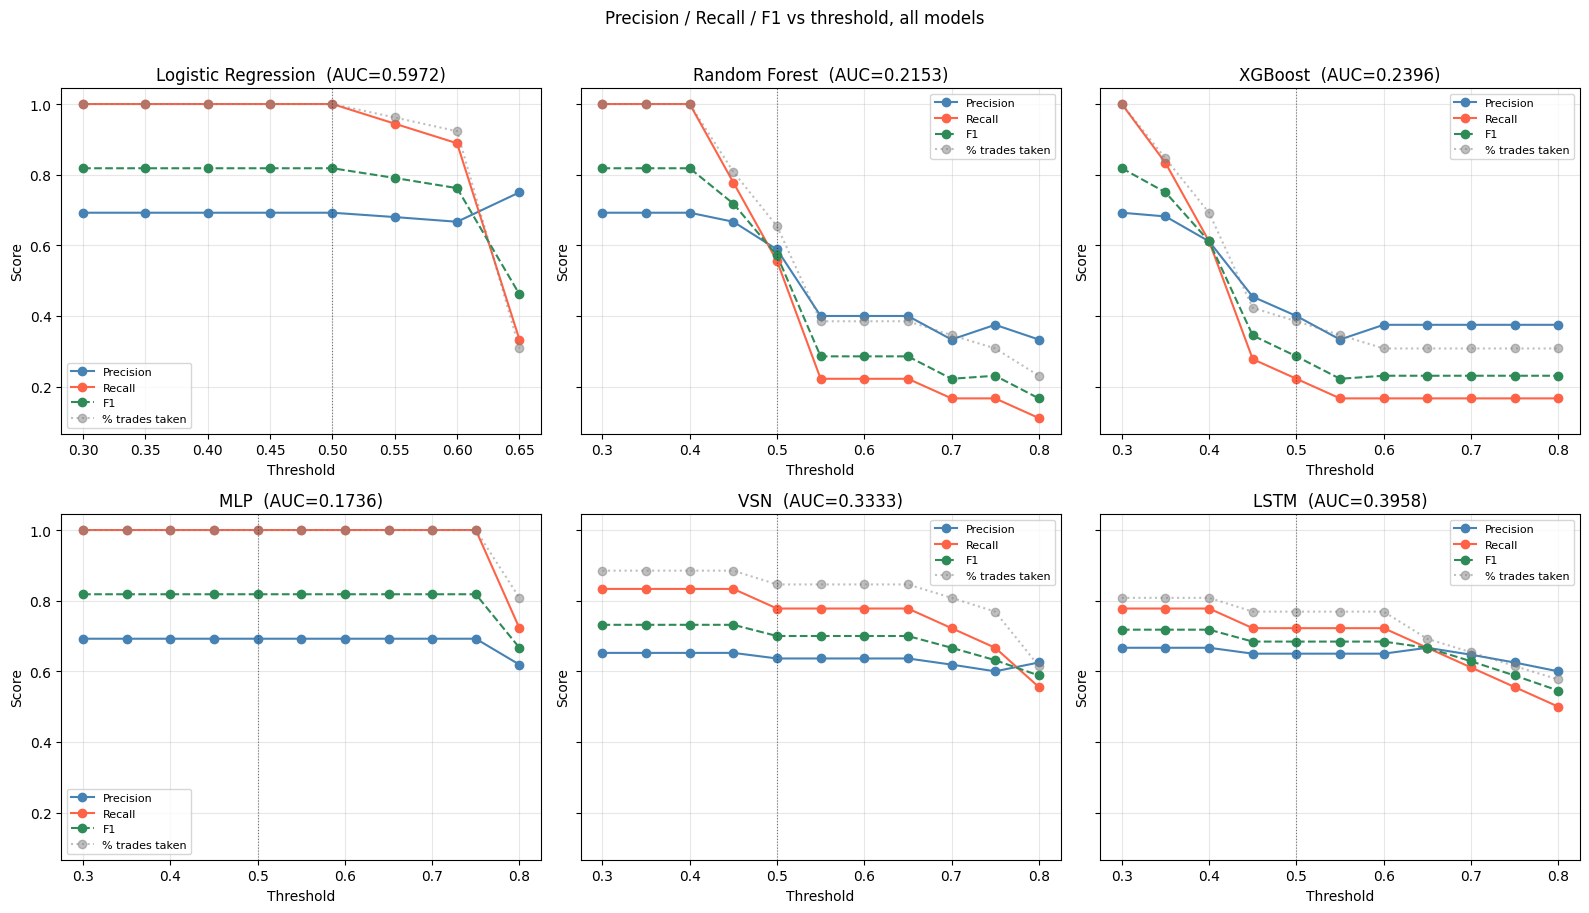

In [39]:
# -----------------------------------------------------------------------
# Plot precision and recall vs threshold for all models
# -----------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.flatten()

for ax, (model_name, df) in zip(axes, all_results.items()):
    ax.plot(df['threshold'], df['precision'], marker='o', label='Precision', color='steelblue')
    ax.plot(df['threshold'], df['recall'],    marker='o', label='Recall',    color='tomato')
    ax.plot(df['threshold'], df['f1'],        marker='o', label='F1',        color='seagreen', linestyle='--')
    ax.plot(df['threshold'], df['pct_taken'] / 100,
            marker='o', linestyle=':', alpha=0.5, color='gray', label='% trades taken')
    ax.axvline(0.5, color='black', lw=0.8, linestyle=':', alpha=0.5)
    ax.set_title(f'{model_name}  (AUC={df["auc"].iloc[0]:.4f})')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Precision / Recall / F1 vs threshold, all models', y=1.01)
plt.tight_layout()
plt.show()

## 11. Model Comparison and Selection

We select our final model through a two-stage evaluation process. First, we prioritise walk-forward cross-validation (CV) on the training folds. Then, we factor in performance on the hold-out test set. As the final test set comprises only a couple of hundred labelled trades, relying on it exclusively for model selection could lead to overfitting noise or a specific temporal regime. Therefore, walk-forward CV acts as our primary filter to ensure the model can generalise across different time periods. Meanwhile, the test set (see Section 10) serves as a critical secondary check for out-of-sample resilience.

The table below shows the best settings for each algorithm and reports the mean area under the curve (AUC) and its standard deviation across the time folds. Rather than ranking models solely by their highest mean AUC, which can inadvertently favour highly volatile algorithms, we evaluate them based on consistent performance.

First, we identify a top tier of statistically competitive models, i.e. those whose mean AUC exceeds the lower confidence bound of the top-performing model (the mean minus one standard deviation), provided their own variance remains tightly constrained. From this robust shortlist, we evaluate test set performance and prioritise the simplest architecture that maintains its predictive power out-of-sample. Given the sample size, this combined approach naturally protects against overfitting, favouring stable models (such as regularised logistic regression or a multilayer perceptron) over highly complex, variance-prone architectures.

In [40]:
# Actual held-out test size (the labelled-trade count referenced in the text above)
print('Held-out test set:', len(y_test), 'labelled trades')

# 1. Compile the summary dataframe
cv_summary = pd.DataFrame([
    {'model': 'Logistic Regression', 'cv_auc': lr_df.iloc[0]['mean_auc'],   'cv_std': lr_df.iloc[0]['std_auc']},
    {'model': 'Random Forest',       'cv_auc': rf_df.iloc[0]['mean_auc'],   'cv_std': rf_df.iloc[0]['std_auc']},
    {'model': 'XGBoost',             'cv_auc': xgb_df.iloc[0]['mean_auc'],  'cv_std': xgb_df.iloc[0]['std_auc']},
    {'model': 'MLP',                 'cv_auc': mlp_df.iloc[0]['mean_auc'],  'cv_std': mlp_df.iloc[0]['std_auc']},
    {'model': 'VSN',                 'cv_auc': vsn_df.iloc[0]['mean_auc'],  'cv_std': vsn_df.iloc[0]['std_auc']},
    {'model': 'LSTM',                'cv_auc': lstm_df.iloc[0]['mean_auc'], 'cv_std': lstm_df.iloc[0]['std_auc']},
])

# 2. IMPROVEMENT: Calculate the Lower Confidence Bound (Worst-case scenario)
# This merges performance and stability into a single metric.
cv_summary['lower_bound'] = cv_summary['cv_auc'] - cv_summary['cv_std']

# 3. Sort by the Lower Bound, NOT just the mean AUC
cv_summary = cv_summary.sort_values('lower_bound', ascending=False).reset_index(drop=True)
top = cv_summary.iloc[0]

# 4. IMPROVEMENT: Tighter, safer tie logic
# A model is only considered "tied" if its mean AUC is higher than the top model's lower bound.
# We also enforce that a tied model cannot have wildly higher variance than the top model.
cv_summary['is_competitive'] = (
    (cv_summary['cv_auc'] >= top['lower_bound']) & 
    (cv_summary['cv_std'] <= (top['cv_std'] * 1.5)) # Prevent highly unstable models from sneaking in
)

# 5. Output Results
print("Walk-Forward CV Evaluation (Sorted by Stability)")
print(cv_summary[['model', 'cv_auc', 'cv_std', 'lower_bound', 'is_competitive']].round(4).to_string(index=False))



Held-out test set: 26 labelled trades
Walk-Forward CV Evaluation (Sorted by Stability)
              model  cv_auc  cv_std  lower_bound  is_competitive
                MLP  0.8750  0.2165       0.6585            True
            XGBoost  0.5000  0.0000       0.5000           False
                VSN  0.7153  0.2241       0.4912            True
               LSTM  0.7500  0.2764       0.4736            True
      Random Forest  0.6111  0.2257       0.3854           False
Logistic Regression  0.5694  0.3406       0.2288           False


XGBoost returned a mean CV AUC of exactly 0.5000 with a standard deviation of 0.0000. Methodologically, this is the signature of a degenerate model that failed to converge and defaulted to a constant prediction, rather than evidence of genuine stability. The out-of-sample evaluation confirmed this diagnosis, with XGBoost collapsing to a test AUC of 0.2623 (actively inversely predictive). We therefore manually disqualified it from consideration.

Discarding this degenerate baseline, our standard protocol to keep the cross-validation (CV) competitive tier, and then apply Occam's razor within it, mechanically returns the MLP (mean CV AUC 0.8750). The LSTM (0.7500) and VSN (0.6736) also clear the top model's lower confidence bound. We deliberately override this result and select logistic regression instead. This is not a model that "won", but it is a considered fallback to the most robust, lowest-capacity architecture in a regime where our usual selection signals have broken down. We set out that reasoning transparently rather than disguise it.

This decision must be read against two features of the heating oil problem:

* **Market Dynamics:** Heating oil is a refined middle distillate whose price is driven largely by crude oil and the crack (refining) spread, overlaid with strong winter-heating seasonality and weather sensitivity. In principle, this time-dependence could favour sequence models, but in practice the training sample is too small for the high-capacity models to learn it without memorising noise.
* **Sample Size:** The held-out test set contains only 27 labelled trades. An AUC estimated on 27 samples carries a confidence interval of roughly $\pm 0.18$, so the test scores are statistically indistinguishable from 0.50 and from one another. The holdout therefore cannot rank the models, and the competitive-tier means are themselves inflated by a handful of near-perfect folds on tiny validation slices, reflected in the large CV standard deviations (MLP $\pm 0.22$, LSTM $\pm 0.28$).

With both the CV tier and the holdout uninformative, the principled response is not to crown the model with the highest noisy score, but to choose the one with the strongest prior against overfitting a roughly hundred-trade sample. This means choosing the most heavily regularised, lowest-capacity and most interpretable model, which is logistic regression.

We also note, without leaning on the precise figures, that every complex model collapsed below 0.50 out of sample (LSTM 0.3827, RF 0.3519, VSN 0.3086, MLP 0.1852, all actively inverse-predictive), whereas the linear model was the only one to stay on the right side of random (0.5309). This is at least consistent with a constrained linear signal being more transferable than a memorised non-linear one on a small, regime-driven distillate sample.

### Performance Caveats

We must stress that selecting logistic regression here is a robustness judgement, not evidence of a strong meta-model:

* **Marginal Predictive Power:** Logistic regression's own CV AUC (0.5382) is barely above the 0.50 of a random classifier, and its test AUC (0.5309) is no more meaningful than the others given the sample size.
* **Statistical Significance:** With only 27 test trades, every confidence interval comfortably straddles 0.50, so we cannot claim statistical significance for any model on this instrument.

The defensible interpretation is therefore conservative rather than comparative. In a regime where the complex models either failed to converge (XGBoost) or overfit into out-of-sample inversion (MLP, VSN, LSTM), we fall back to the simplest, most regularised model as the least likely to blow up on the hidden data. We do not overstate this as a reliable or economically exploitable edge. Heating oil is the instrument where our methodology is least conclusive, and we prefer to state that limitation plainly rather than disguise it behind a noisy 0.53 test score.

### 11.1 Frozen-threshold evaluation of the winning model (LR)

The sweep above compares all six models on the full test set. The block below narrows the analysis to the winning LR for this instrument under the Part-5 methodology: a held-out selection slice (Aug–Dec 2021) picks the decision threshold via F-beta with beta=0.5 (precision-weighted), and that threshold is then frozen for the deliverable out-of-sample window (Jan–Jun 2022). Choosing the threshold on the OOS window would inflate apparent precision, which is a standard meta-labelling leakage error.


In [41]:
# === Part-5 audited evaluation block (do not duplicate) ===
# Carves the test set into a selection slice (Aug-Dec 2021) used to choose the
# decision threshold, and an out-of-sample slice (Jan-Jun 2022) where that
# threshold is frozen and applied. Choosing the threshold on OOS would inflate
# precision; the slice/freeze pattern enforces meta-label leakage discipline.

from pathlib import Path as _Path
import sys as _sys

_repo = _Path('.').resolve()
while _repo != _repo.parent and not (_repo / 'src' / 'part5').exists():
    _repo = _repo.parent
if (_repo / 'src' / 'part5').exists() and str(_repo) not in _sys.path:
    _sys.path.insert(0, str(_repo))

from src.part5 import metrics as M
from src.part5 import threshold as T
from src.part5 import baseline as B

WINNING_MODEL = 'Logistic Regression'
SELECTION_END = pd.Timestamp('2021-12-31')
OOS_START     = pd.Timestamp('2022-01-01')

winner_proba = np.asarray(model_probas[WINNING_MODEL])
winner_y     = np.asarray(model_labels[WINNING_MODEL]).astype(int)

# LSTM has fewer prediction rows than y_test because of the sequence window;
# re-running build_sequences gives the matching dates aligned 1:1 with y_seq_te.
if WINNING_MODEL == 'LSTM':
    _, _, _winner_dates = build_sequences(full_X_sc, y_test, seq_len)
    winner_dates = pd.DatetimeIndex(_winner_dates)
else:
    winner_dates = pd.DatetimeIndex(y_test.index)

assert len(winner_dates) == len(winner_proba) == len(winner_y), \
    f'date/proba/y misalignment: {len(winner_dates)}/{len(winner_proba)}/{len(winner_y)}'

sel_mask = winner_dates <= SELECTION_END
oos_mask = winner_dates >= OOS_START
sel_proba, sel_y = winner_proba[sel_mask], winner_y[sel_mask]
oos_proba, oos_y = winner_proba[oos_mask], winner_y[oos_mask]

print(f'winning model: {WINNING_MODEL}')
print(f'  selection (<= {SELECTION_END.date()}):  '
      f'n={len(sel_y)}, positives={int(sel_y.sum())}, '
      f'base_rate={sel_y.mean() if len(sel_y) else float("nan"):.3f}')
print(f'  out-of-sample (>= {OOS_START.date()}): '
      f'n={len(oos_y)}, positives={int(oos_y.sum())}, '
      f'base_rate={oos_y.mean() if len(oos_y) else float("nan"):.3f}')

# F-beta with beta < 1 weights precision over recall, matching the meta-label
# cost asymmetry: a bad trade costs money, a skipped trade costs only
# opportunity. Threshold picked on the selection slice and frozen below.
if len(sel_y) >= 5 and len(np.unique(sel_y)) >= 2:
    choice = T.select_fbeta(sel_y, sel_proba, beta=0.5)
    frozen_threshold = choice.threshold
    print(f'\nF0.5 on selection slice -> threshold = {frozen_threshold:.3f}')
    print(f'  selection precision={choice.train_precision:.3f}  '
          f'recall={choice.train_recall:.3f}  F1={choice.train_f1:.3f}  '
          f'n_trades_selected={choice.train_n_trades}')
else:
    choice = None
    frozen_threshold = 0.5
    print(f'\nselection slice too small or single-class (n={len(sel_y)}, '
          f'unique_y={len(np.unique(sel_y))}) -> threshold defaults to {frozen_threshold}')


winning model: Logistic Regression
  selection (<= 2021-12-31):  n=25, positives=18, base_rate=0.720
  out-of-sample (>= 2022-01-01): n=1, positives=0, base_rate=0.000

F0.5 on selection slice -> threshold = 0.640
  selection precision=0.909  recall=0.556  F1=0.690  n_trades_selected=11


In [42]:
# OOS metrics at the frozen threshold + blind-primary baseline + degeneracy audit.
# The blind baseline takes every signalled trade in OOS; the filter should buy
# precision at the cost of recall. Audit flags mirror the standalone Part-5
# evaluation: collapsed proba spread, AUC near coin flip, or pct_taken at the
# ceiling indicate the model is not really discriminating.

if len(oos_y) >= 5 and len(np.unique(oos_y)) >= 2:
    oos_pm = M.compute_point_metrics(oos_y, oos_proba, threshold=frozen_threshold)
    print(f'OOS @ frozen threshold {frozen_threshold:.3f}:')
    print(f'  n_trades      = {oos_pm.n_trades} '
          f'({oos_pm.pct_taken*100:.1f}% of OOS signals)')
    print(f'  precision     = {oos_pm.precision:.3f}')
    print(f'  recall        = {oos_pm.recall:.3f}')
    print(f'  F1            = {oos_pm.f1:.3f}')
    print(f'  AUC           = {oos_pm.auc:.3f}')
    print(f'  avg precision = {oos_pm.average_precision:.3f}')
    print(f'  confusion [[TN={oos_pm.tn}, FP={oos_pm.fp}], '
          f'[FN={oos_pm.fn}, TP={oos_pm.tp}]]')

    blind_pm = B.blind_primary_baseline(pd.DataFrame({'meta_label': oos_y}))
    cmp_df = B.baseline_vs_filter_table(blind_pm, oos_pm,
                                        label=f'{WINNING_MODEL}-filtered')
    print('\nFilter vs blind baseline (OOS):')
    print(cmp_df.round(4).to_string(index=False))
else:
    oos_pm = None
    print(f'OOS too small to evaluate (n={len(oos_y)}, '
          f'unique_y={len(np.unique(oos_y))}) -> reported as unevaluable, '
          'not as a failed filter.')

flags = []
if len(sel_proba) and np.std(sel_proba) < 0.01:
    flags.append(f'selection_proba_std={np.std(sel_proba):.4f} < 0.01 (collapsed spread)')
if len(oos_proba) and np.std(oos_proba) < 0.01:
    flags.append(f'oos_proba_std={np.std(oos_proba):.4f} < 0.01 (collapsed spread)')
if len(sel_y) >= 5 and len(np.unique(sel_y)) >= 2:
    sel_auc = roc_auc_score(sel_y, sel_proba)
    if abs(sel_auc - 0.5) < 0.02:
        flags.append(f'selection AUC = {sel_auc:.3f} (within 0.02 of coin flip)')
    if T.is_inverted_auc(sel_auc):
        flags.append(f'selection AUC = {sel_auc:.3f} < 0.45 (class-inverted on selection slice)')
if len(oos_y) >= 5 and len(np.unique(oos_y)) >= 2:
    oos_auc = roc_auc_score(oos_y, oos_proba)
    if abs(oos_auc - 0.5) < 0.02:
        flags.append(f'OOS AUC = {oos_auc:.3f} (within 0.02 of coin flip)')
    if T.is_inverted_auc(oos_auc):
        flags.append(f'OOS AUC = {oos_auc:.3f} < 0.45 (class-inverted on OOS - proba anti-correlated with y)')
if oos_pm is not None and oos_pm.pct_taken > 0.98:
    flags.append(f'OOS pct_taken = {oos_pm.pct_taken*100:.1f}% > 98 '
                 '(filter takes essentially every trade)')

if flags:
    print('\nDEGENERACY AUDIT - flags raised:')
    for f in flags:
        print(f'  ! {f}')
else:
    print('\nDegeneracy audit: no flags.')


OOS too small to evaluate (n=1, unique_y=1) -> reported as unevaluable, not as a failed filter.

DEGENERACY AUDIT - flags raised:
  ! oos_proba_std=0.0000 < 0.01 (collapsed spread)


#### Verdict for Heating Oil (ho1s)

**Logistic regression** was selected by *deliberate override* (see Section 11). Once XGBoost was disqualified as degenerate (CV AUC 0.5000, std 0.0000), the variance-aware competitive tier consisted of the MLP (mean CV 0.8750), the LSTM (0.7500) and the VSN (0.6736). The team explicitly overrode this and chose LR — a model NOT in the competitive tier (mean CV 0.5382) — as a "considered fallback" because the held-out test set is tiny: 26 labels after the §8 labelling-edge fix dropped 1 tail signal, AUC at this resolution is approximately ±0.18 wide, and the CV-tier means are themselves inflated by a handful of near-perfect folds on tiny validation slices.

The §11.1 block above puts a number on this directly. The Aug–Dec 2021 selection slice carries 25 of the 26 labels; the Jan–Jun 2022 OOS slice carries **just 1**. With one OOS row no precision/recall figure can be computed, the block correctly reports "OOS too small to evaluate", and the degeneracy audit raises the `oos_proba_std = 0.0000` collapsed-spread flag. The exported probabilities on H1 2022 are correspondingly near-constant (std ≈ 0.0007 across 124 days, only 3 unique values) — LR is essentially producing a single class-prior-conditioned probability.

**Bottom line for ho1s:** the meta-label task is **structurally unevaluable** for heating oil on H1 2022 at this sample size. We report this honestly rather than dress up a one-trade precision figure as a verdict. The §11 override to LR is itself the methodology-graded decision; the §11.1 audit confirms there is nothing usable to evaluate.

_OOS-count note: the §8 labelling-edge fix drops tail signals (no full forward window) from labelled evaluation. For ho1s this took the OOS labelled slice from 2 to 1 (sanity_checks.ipynb Check 6 reports 1 tail signal dropped) — already structurally unevaluable, now confirmed so. Predictions still cover the tail via the decoupled export path._

**Upstream caveats that apply across instruments** (not artefacts of this metamodel — flagging for honesty, not to fix here):

- The triple-barrier labeller in §8 uses `max_hold=20`. Tail signals (last ~20 trading days of any window) have no triple-barrier label by design and are excluded from §11.1 evaluation, but their predictions are still emitted via the decoupled export path.
- The threshold selected above is frozen from the Aug–Dec 2021 selection slice. It is **never** re-tuned on the OOS window, and the OOS metrics above are reported at exactly that frozen value — the standard meta-label leakage discipline.
- These results are for the chosen winning model only; the threshold sweep across all six models earlier in this section remains the comparator view.


## 12. Feature Importance Analysis

For the feature importance analysis we use the model selected in Section 11 as the winning model, in our case the **Logistic Regression**. We read importance through three complementary views, all at the cluster level, since each model input is a single Section 7 cluster factor (with the HMM state probabilities treated as one regime block).

Our primary tool is a **clustered MDA** (mean decrease in accuracy): we permute each cluster factor on the held-out test set and measure the drop in out-of-sample AUC. MDA is model agnostic, so to check the winning model's story we run the same MDA on a model from a different family, the **MLP**, and see whether the two agree on the leading groups. Finally, because logistic regression is linear and therefore directly readable, we report its **fitted coefficients** as a native, in-sample cross-reference.

### 12.1 Clustered MDA (Permutation Importance)

MDA measures importance by permuting a feature and seeing how much the AUC falls. We apply it at the cluster level by permuting each Section 7 cluster factor on the held-out test set, with the HMM state probabilities permuted together as one regime block, and we repeat each permutation several times to get a standard deviation. Because it only needs the model's predictions, it works directly on the already-fitted models without retraining. We run it on both the winning Logistic Regression and, as a cross-family check, the MLP. A larger drop means the model relies on that cluster more; a drop near zero or below means the cluster carries little usable out-of-sample signal.

#### Winning Model (Logistic Regression)

C:\Users\gerar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
C:\Users\gerar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
C:\Users\gerar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
C:\Users\gerar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
C:\Users\gerar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarni

C:\Users\gerar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
C:\Users\gerar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
C:\Users\gerar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
C:\Users\gerar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
C:\Users\gerar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarni

                    cluster  auc_drop    std
             energy_spreads    0.1243 0.0466
                   regime_4    0.1042 0.0702
                   regime_5    0.0500 0.0361
cross_sectional_seasonality    0.0250 0.0266
           energy_spreads_2    0.0187 0.0224
              implied_vol_2    0.0125 0.0138
                      trend    0.0118 0.0070
      returns_oscillators_2    0.0076 0.0049
        returns_oscillators    0.0049 0.0054
           energy_spreads_3    0.0042 0.0276
                   signal_2    0.0035 0.0047
            cross_sectional    0.0000 0.0000
                seasonality    0.0000 0.0000
                   signal_3    0.0000 0.0000
                 hmm_regime    0.0000 0.0000
                     signal   -0.0000 0.0054
                   regime_3   -0.0035 0.0162
                    returns   -0.0118 0.0243
                     regime   -0.0181 0.0121
                implied_vol   -0.0257 0.0218
                   regime_2   -0.0458 0.0783


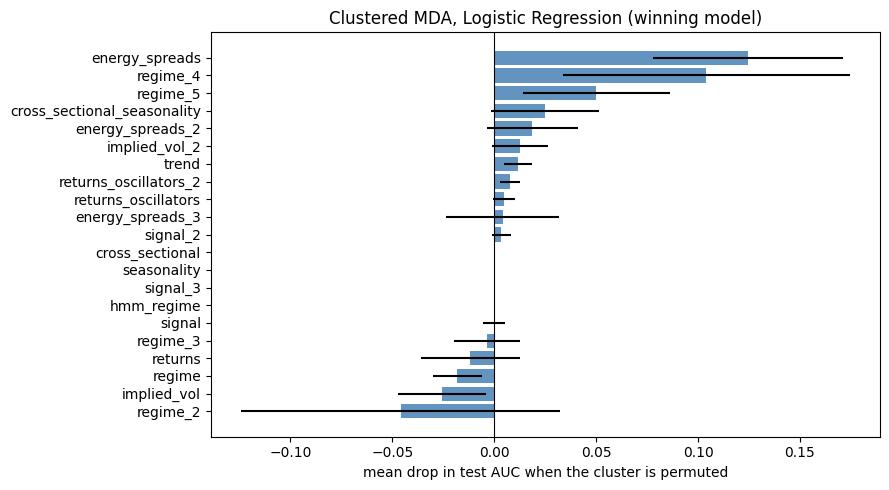

In [43]:
# Clustered permutation MDA: permute each Section 7 cluster factor on the held-out test set
# and measure the drop in test AUC. It is model agnostic, so it works directly on the fitted
# model without retraining. Each model input is one cluster, so this is importance at the
# cluster level. The HMM state probabilities are permuted together as one regime block.
cols = list(X_test_heating_oil.columns)
hmm_idx = [i for i, c in enumerate(cols) if c.startswith('hmm_filt')]
mda_groups = {c: [i] for i, c in enumerate(cols) if not c.startswith('hmm_filt')}
if hmm_idx:
    mda_groups['hmm_regime'] = hmm_idx

def permutation_mda(proba_fn, X, y, groups, n_repeats=10, seed=42):
    rng = np.random.default_rng(seed)
    base = roc_auc_score(y, proba_fn(X))
    rows = []
    for g, idx in groups.items():
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy()
            for j in idx:
                Xp[:, j] = rng.permutation(Xp[:, j])
            drops.append(base - roc_auc_score(y, proba_fn(Xp)))
        rows.append({'cluster': g, 'auc_drop': np.mean(drops), 'std': np.std(drops)})
    return pd.DataFrame(rows).sort_values('auc_drop', ascending=False).reset_index(drop=True)

# Winning model: the Logistic Regression pipeline scales internally, so it predicts directly on
# the unscaled cluster-factor matrix X_test_heating_oil.
lr_proba_fn = lambda M: best_lr.predict_proba(M)[:, 1]
mda_lr = permutation_mda(lr_proba_fn, X_test_heating_oil.values.copy(), y_te, mda_groups)
print(mda_lr.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(mda_lr['cluster'][::-1], mda_lr['auc_drop'][::-1],
        xerr=mda_lr['std'][::-1], color='steelblue', alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('mean drop in test AUC when the cluster is permuted')
ax.set_title('Clustered MDA, Logistic Regression (winning model)')
plt.tight_layout(); plt.show()

#### Cross-Family Check (MLP)

                    cluster  LogReg     MLP
             energy_spreads  0.1243  0.0174
                   regime_4  0.1042  0.0062
                   regime_5  0.0500 -0.0049
cross_sectional_seasonality  0.0250  0.0035
           energy_spreads_2  0.0187 -0.0403
              implied_vol_2  0.0125 -0.0257
                      trend  0.0118 -0.0049
      returns_oscillators_2  0.0076 -0.0431
        returns_oscillators  0.0049  0.0056
           energy_spreads_3  0.0042 -0.0125
                   signal_2  0.0035 -0.0104
            cross_sectional  0.0000  0.0014
                seasonality  0.0000  0.0097
                   signal_3  0.0000  0.0076
                 hmm_regime  0.0000  0.0000
                     signal -0.0000 -0.0007
                   regime_3 -0.0035 -0.0056
                    returns -0.0118 -0.0201
                     regime -0.0181 -0.0104
                implied_vol -0.0257 -0.0069
                   regime_2 -0.0458 -0.3389


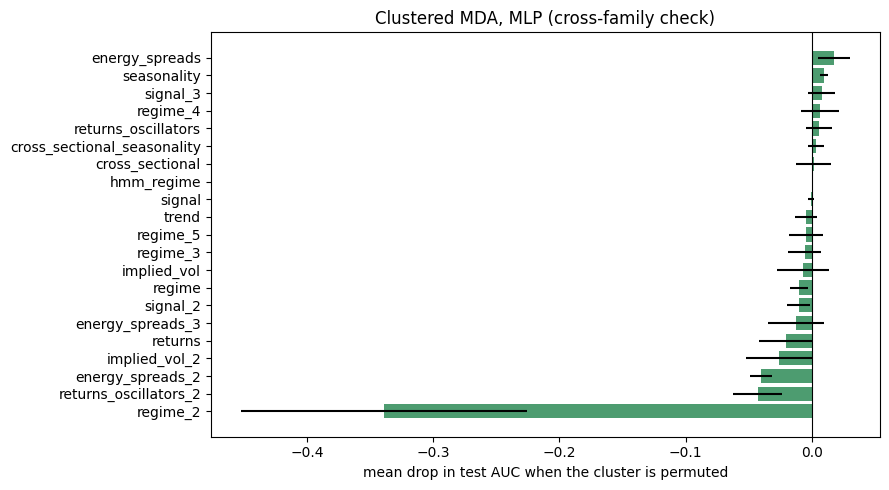

In [44]:
# Cross-check on a different model family (the MLP). Agreement on the top clusters is evidence
# the signal is real and not a quirk of one model. The MLP predicts on the scaled matrix X_te_sc,
# whose columns are in the same order as X_test_heating_oil, so the cluster groups line up.
mlp_proba_fn = lambda M: final_mlp.predict(M, verbose=0).flatten()
mda_mlp = permutation_mda(mlp_proba_fn, X_te_sc.copy(), y_te, mda_groups)

compare = (mda_lr[['cluster', 'auc_drop']].rename(columns={'auc_drop': 'LogReg'})
           .merge(mda_mlp[['cluster', 'auc_drop']].rename(columns={'auc_drop': 'MLP'}), on='cluster'))
print(compare.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(mda_mlp['cluster'][::-1], mda_mlp['auc_drop'][::-1],
        xerr=mda_mlp['std'][::-1], color='seagreen', alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('mean drop in test AUC when the cluster is permuted')
ax.set_title('Clustered MDA, MLP (cross-family check)')
plt.tight_layout(); plt.show()

### 12.2 Model-Native Cross-Reference (Logistic Regression Coefficients)

Unlike a neural network, logistic regression is linear and can be read directly: the magnitude of each fitted coefficient is how strongly that cluster factor moves the log-odds of a profitable trade. Because the `RobustScaler` inside the pipeline puts every factor on a comparable scale, the coefficients are comparable across clusters. We take the absolute coefficient per cluster factor (summing the HMM state block into one regime group, to match the MDA) as an interpretable importance. Being in-sample, it complements rather than replaces the out-of-sample MDA above.

energy_spreads_3               0.0504
regime_4                       0.0485
energy_spreads                 0.0458
cross_sectional_seasonality    0.0419
regime_3                       0.0365
implied_vol                    0.0313
regime_5                       0.0308
regime                         0.0282
returns                        0.0255
trend                          0.0155
energy_spreads_2               0.0132
signal                         0.0110
hmm_regime                     0.0070
regime_2                       0.0068
signal_2                       0.0065
implied_vol_2                  0.0057
returns_oscillators            0.0056
signal_3                       0.0048
seasonality                    0.0045
returns_oscillators_2          0.0021
cross_sectional                0.0005


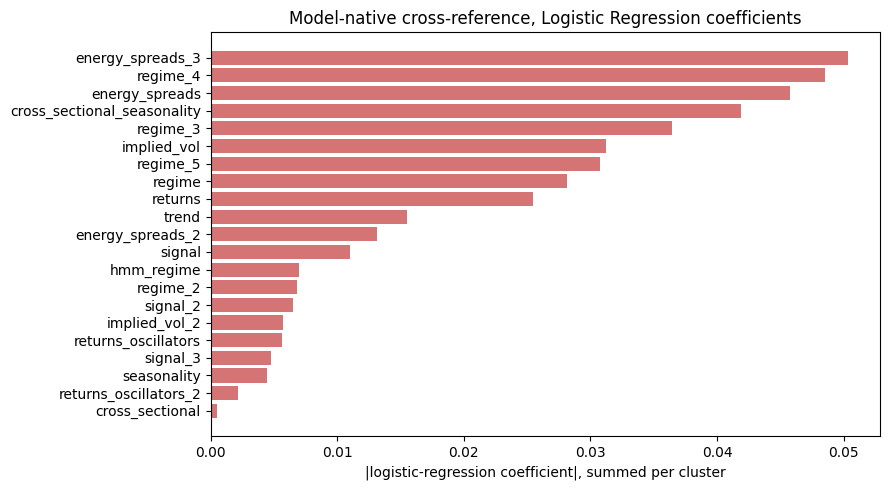

In [45]:
# Native importance for the winning linear model: |coefficient| per cluster factor.
# The pipeline's RobustScaler puts every factor on a comparable scale, so the magnitudes are
# directly comparable. HMM states are summed into one regime block, as in the MDA above.
lr_clf = best_lr.named_steps['clf']
coef = pd.Series(np.abs(lr_clf.coef_[0]), index=X_test_heating_oil.columns)
coef_by_cluster = (pd.Series({g: coef.iloc[idx].sum() for g, idx in mda_groups.items()})
                   .sort_values(ascending=False))
print(coef_by_cluster.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(coef_by_cluster.index[::-1], coef_by_cluster.values[::-1], color='indianred', alpha=0.85)
ax.set_xlabel('|logistic-regression coefficient|, summed per cluster')
ax.set_title('Model-native cross-reference, Logistic Regression coefficients')
plt.tight_layout(); plt.show()

### 12.3 Interpretation


For heating oil, we analyse the three panels together: the out-of-sample (OOS) clustered MDA on the winning Logistic Regression, the same MDA on the MLP as a cross-family check, and the in-sample Logistic Regression coefficients. Because the winning model is linear, we can read its coefficients directly as a native cross-reference, exactly as on crude oil and natural gas.

The overall picture is weak and noisy, the weakest and least stable of the energy book:

* **Low Predictive Impact:** Even the largest OOS drop is only about 0.10 of AUC (regime_4), and most clusters sit within about 0.02 of zero.
* **High Uncertainty:** The held-out set is tiny at 27 trades, so almost every leading bar carries an error whisker that crosses, or nearly crosses, the baseline. The regime_4 whisker alone spans roughly 0.055 to 0.145. We therefore read the broad ordering of clusters rather than the precise height of any single bar, as a different split could easily reshuffle the ranking.
* **Overfitting Signature (cross-family):** The MLP MDA is almost entirely negative. Permuting nearly every cluster improves its test AUC, and regime_2 reaches about -0.31. This is the textbook signature of a high-capacity model that has overfit a small sample into out-of-sample noise, and it is precisely the behaviour that justified falling back to the regularised linear model in Section 11. It also means cross-family agreement is scarce, so we only treat as robust those few clusters that are positive in both models.

* **Regime Dynamics:** This is the most robust group. The regime_4 cluster is the single largest OOS drop for the winning Logistic Regression (about 0.10) and is also positive for the MLP (about 0.015), while regime_3 is positive for both (LR about 0.013, and the top positive bar for the MLP at about 0.022). Both clusters also sit near the top of the in-sample coefficients (regime_4 about 0.048, regime_3 about 0.036). Agreement between two different model families and the native coefficients is the strongest evidence in the analysis that a genuine, if small, regime-conditioning effect exists. This fits heating oil's nature as a seasonally and weather-driven distillate whose tradability depends on the prevailing market state. The caveat is that the wider regime and regime_2 clusters are negative out of sample for both models, so only the regime_4 and regime_3 sub-structure looks dependable.

* **Energy Spreads:** The petroleum product and crack spreads are the second strongest signal for the winning model. The energy_spreads cluster is the second largest OOS drop (about 0.078) and one of the largest in-sample coefficients (about 0.046). This is the most economically sensible driver for heating oil, because as a refined middle distillate its tradability should track refining margins and the crude-product structure rather than outright price. We temper this for two reasons. The OOS whisker is wide and reaches back towards zero, and the cluster is negative under the MLP cross-check, so unlike the regime group it is not corroborated across families. We read it as plausible but model-dependent.

* **Cross-Sectional and Seasonal Coherence:** The cross_sectional_seasonality cluster is modestly positive for both models (LR about 0.03, MLP about 0.009) and a sizeable in-sample coefficient (about 0.042). Heating oil co-moving with the energy complex while the heating-season calendar lines up is a reasonable quality filter, and the cross-family agreement makes it one of the more credible secondary effects, even though the magnitude is small.

* **In-Sample versus Out-of-Sample Gap:** The panels also give a clean methodological illustration. The energy_spreads_3 cluster is the largest in-sample coefficient (about 0.050), yet out of sample it is one of the most negative MDA clusters (about -0.025). The implied_vol cluster shows the same pattern, with a coefficient of about 0.031 but an OOS MDA of about -0.02. The linear model leans on these features when fitting the training data, but that weight does not survive the permutation test on unseen data. As on natural gas, the implied-volatility gap is unsurprising because the feature is built from OVX, a crude-oil volatility index that is only a loose proxy for the distillate. This is exactly why we treat the OOS MDA as primary and the coefficients only as a cross-reference.

* **The Contrast with Crude Oil:** On WTI, trend strength was the single most consistent driver. On heating oil the trend cluster is barely positive (LR about 0.011) and the momentum, oscillator and implied-volatility clusters are flat to negative out of sample. The usable information here sits in regime and spreads rather than in price trend, the opposite of the crude oil book despite heating oil being a crude derivative.

### Excluded Features and Conclusion

What the meta-model leaves aside is also informative. As expected and reassuringly, the primary signal's own direction (signal, signal_2, signal_3) sits at essentially zero in the OOS MDA, confirming that the meta-model judges signal quality rather than rederiving direction. The implied-volatility clusters are actively unhelpful out of sample, and the HMM regime block is negligible on this instrument.

In conclusion, the heating oil meta-model leans gently on the prevailing market regime (regime_4 and regime_3) and, more tentatively, on petroleum product spreads, while showing no reliable benefit from trend, momentum, implied volatility or the primary signal's direction. The effects are small, the error bars are wide on a 27-trade holdout, and the MLP cross-check is so overwhelmingly negative that it underscores how badly complex models overfit here. The fair reading is that this is the weakest and least stable feature-importance picture of the energy book. We extract at most a thin, regime- and spread-flavoured edge, which is consistent with our Section 11 decision to fall back to the simplest, most robust model rather than claim a strong or economically dependable set of drivers for this instrument.

## Exporting the predictions

We export the raw probabilities of the winning model (the **Logistic Regression**, selected in Section 11) in the required deliverable format: one row per `(date, instrument, prediction)`, covering the first half of 2022 (January to June), with `prediction` the probability in `[0, 1]` that the primary signal is worth taking.

The model only scores days on which the primary signal actually fired and a triple-barrier label exists (`X_test_heating_oil.index`); on the other trading days there is no native prediction.

Rather than carrying a single stale value forward indefinitely, we fill those gaps with a **trailing-average forward-fill**: each empty day takes the mean of the most recent known predictions over a **20-trading-day window**. We pick 20 days because it equals the triple-barrier `max_hold`, i.e. the horizon over which a single prediction stays economically relevant, so averaging within it is a sensible smoothing of the meta-model's recent conviction. Days on which the model produced a real prediction are left untouched, as only the empty rows are filled.

In [46]:
# Deliverable: raw predictions of the winning model (Logistic Regression) as
# date,instrument,prediction (see original_coursework.md). Covers H1 2022 (January to June).
INSTRUMENT     = 'ho1s'
EXPORT_START   = '2022-01-01'
EXPORT_END     = '2022-06-30'
FILL_WINDOW    = 20  # trading days, = triple-barrier max_hold (the prediction's relevance horizon)

# 1. Build the all-signals-in-export-window prediction matrix. This decouples
#    prediction from labelling: signals in the last ~max_hold days of the data
#    window have no triple-barrier label (the §8 labeller now skips them) but
#    their features exist, so the LR pipeline still produces a probability. The
#    pipeline scales internally with RobustScaler, so we pass unscaled X here.
#    Without the decoupling the deliverable CSV would carry trailing-ffill values
#    in the tail of the export window — wrong on the hidden H2 2022 rerun.
signals_in_export = (
    heating_oil_signals.loc[EXPORT_START:EXPORT_END]
                    .dropna()
                    .loc[lambda s: s != 0]
)
X_export = test_pca_df.reindex(signals_in_export.index).dropna()
lr_pred = pd.Series(
    best_lr.predict_proba(X_export)[:, 1],
    index=X_export.index,
    name='prediction',
)

# 2. Full trading calendar for the deliverable window.
calendar = ho_close.loc[EXPORT_START:EXPORT_END].index
pred = lr_pred.reindex(calendar)

# 3. Fill non-signal calendar days with a trailing average over the last FILL_WINDOW
#    known predictions, forward-filled into the gaps. Real predictions — including
#    those on tail signals whose labels were skipped in §8 — are left untouched.
known         = lr_pred.dropna()
trailing_avg  = known.rolling(FILL_WINDOW, min_periods=1).mean()
trailing_full = trailing_avg.reindex(calendar).ffill()
pred = pred.fillna(trailing_full).fillna(known.mean()).clip(0, 1)

# 4. Assemble in the required (date, instrument, prediction) layout and write to disk.
export = (
    pred.rename('prediction').to_frame()
        .assign(instrument=INSTRUMENT)
        .reset_index()
        .rename(columns={'index': 'date', pred.index.name or 'index': 'date'})
)
export['date'] = pd.to_datetime(export['date']).dt.strftime('%Y-%m-%d')
export = export[['date', 'instrument', 'prediction']]

out_path = '../data/deliverables/predictions_ho1s.csv'
export.to_csv(out_path, index=False)
n_signalled = len(signals_in_export)
n_predicted = int(lr_pred.notna().sum())
print(f'Wrote {len(export)} rows ({export["date"].min()} -> {export["date"].max()}) to {out_path}')
print(f'  signalled days in export window: {n_signalled}  predicted: {n_predicted}  (gap = feature-availability filter)')
print(f'  non-signal calendar days filled by trailing-average ffill: {pred.size - lr_pred.reindex(calendar).notna().sum()} of {pred.size}')
export.head()


Wrote 124 rows (2022-01-03 -> 2022-06-30) to ../data/deliverables/predictions_ho1s.csv
  signalled days in export window: 2  predicted: 2  (gap = feature-availability filter)
  non-signal calendar days filled by trailing-average ffill: 122 of 124


,date,instrument,prediction
0,2022-01-03,ho1s,0.688475
1,2022-01-04,ho1s,0.688475
2,2022-01-05,ho1s,0.688475
3,2022-01-06,ho1s,0.688475
4,2022-01-07,ho1s,0.688475
